> **NUEVA CALIBRACIÓN — FULL THETA + SCCM_CORRECTED**
>
> Los tres vectores cinéticos completos se cargan explícitamente desde CSV y se validan contra los
> 17 parámetros esperados antes de simular. Natural y sintético usan sus vectores específicos; el
> vector conjunto `theta_multistart_07.csv` se valida como referencia, pero no sustituye los drivers
> de la matriz objetivo en la transferencia cruzada porque esa es la lógica del notebook SOURCE.
>
> Toda la comparación A/B/C usa **1 SCCM = 0.0404391928807947 g L⁻¹ h⁻¹**. Los parámetros CO₂ de A
> y B son exactamente los guardados por la calibración SCCM-corregida previa; por tanto A→B aísla el
> cambio de theta. Solo C reajusta los nueve parámetros originales de la capa CO₂.
>
> Los notebooks y resultados históricos permanecen inmutables.

# CO₂ 2026 full theta: calibración y validación cruzada

## Resultado que se evalúa

Se conserva la suite científica A–H del SOURCE histórico y se añade la comparación explícita:

- **A — histórico:** theta parcial reconstruido con fallback a `DEFAULT_THETA` + CO₂ histórico SCCM-corregido.
- **B — corrección sin refit:** theta completo correcto + exactamente el mismo CO₂ de A.
- **C — nueva calibración:** theta completo correcto y congelado + refit exclusivo de los nueve parámetros CO₂ originales.

Datos, batches, exclusiones, holdouts, preprocesamiento, objetivo, pesos, bounds, multistart,
arquitectura, gate, O₂, pulso y comparadores se mantienen. `matrix_gain` se interpreta únicamente
como escala empírica de observación, nunca como eficiencia física de recuperación de gas.

# CO₂ 2026: cero de sensor, inicio gradual y validación cruzada

## Resultado que se evalúa

Esta corrida corrige dos fuentes de la cola inicial artificial: la activación casi escalonada de la fuente biológica y la liberación gaseosa nula hasta superar la saturación. La comparación primaria conserva la respuesta de N pero usa la liberación por umbral anterior; el modelo lento legado se conserva como referencia histórica.

- Antes de filtrar, cada corrida recibe una corrección de cero en sccm estimada con el percentil 10 de sus primeras 12 h. El cero no se comparte entre campañas.
- Los archivos exponen canales físicos F1–F3. DOE-F06 conserva la etiqueta solicitada `sensor 6`, aunque se adquiere por F3; el offset se estima por corrida y no depende de agrupar ambas etiquetas.
- La química define el intervalo admisible de activación. Dos parámetros compartidos por matriz sitúan el comienzo y la duración de una rampa suave dentro de esa evidencia; no se estima un retardo libre por lote.
- `O2_qmax_mg_gdw_h` y `O2_initial_scale` se estiman por matriz junto con transferencia, solubilidad y ganancia.
- La fase gaseosa puede recibir un flujo pequeño desde que existe CO₂ disuelto; ya no se exige superar (C^*_{CO_2}) para abandonar exactamente cero.
- El efecto del pulso se construye como la diferencia causal entre simulaciones upstream con y sin adición de N. `pulse_t_rise_h` distribuye su disponibilidad en el tiempo y `pulse_activity_gain` representa capacidad metabólica adicional sin convertirla automáticamente en biomasa.
- En LAB el pulso se ubica por cruce de densidad 1040 g/L; en DOE-F0X se respeta el tiempo de proceso ya registrado en cada fermentación.
- Todos los gráficos de perfil de CO₂ marcan el instante del pulso nutricional.
- A setpoint ≤15.5 °C se usa un umbral operacional más conservador de 0.10 g CO₂ L⁻¹ h⁻¹; en el resto, 0.05.
- Se calibran por separado mosto sintético y natural. DOE-F06 y LAB012 son holdouts completos; después se cruzan los modelos sin reajuste.
- Se excluyen LAB001–LAB003, LAB009 y DOE-F02 por perfiles no confiables.

La analítica química sigue definiendo t=0 y el término del proceso. Esta es una validación de la capa CO₂ condicionada por los drivers upstream disponibles, no una recalibración end-to-end del modelo de fermentación.

## Estructura del modelo

Para la corrida (r), primero se corrige el cero instrumental en la señal nativa:

\[
b_r=\max\left[0,Q_{0.10}\{y_{sccm}(t):t\leq t_0+12\,h\}\right],\qquad
y_{corr}(t)=\max[y_{sccm}(t)-b_r,0]
\]

La conversión a g L⁻¹ h⁻¹, el filtrado de transientes y el suavizado ocurren después. Esta regla supone que el extremo inferior de las primeras 12 h representa cero instrumental; si ya existe flujo biológico durante toda esa ventana, puede sustraer parte de la señal real.

La primera muestra química que cumple pérdida de glucosa+fructosa ≥5 g/L o aumento de etanol ≥2 g/L marca el extremo superior del intervalo de activación. La muestra química anterior fija el extremo inferior. La fuente usa una rampa *smoothstep* continua:

\[
t_s=t_L+f_s(t_U-t_L),\quad
\Delta t=f_d(t_U-t_L),\quad
a_{chem}=3z^2-2z^3,\quad
z=\operatorname{clip}\!\left(\frac{t-t_s}{\Delta t},0,1\right)
\]

Los parámetros (f_s) y (f_d) son compartidos por matriz. Esto permite un aumento pequeño y gradual desde (t_s), pero mantiene el comienzo ligado al bracket químico en vez de introducir una latencia independiente por fermentación.

\[
\frac{dO_2}{dt}=-q_{O_2,max}X\frac{O_2}{K_{O_2}+O_2},\qquad
\phi_{ana}=\frac{K_{ana}^{h}}{K_{ana}^{h}+O_2^{h}}
\]

\[
q_{prod}=a_{chem}(t)\left[q_{bio}\left(f_{Crabtree}+(1-f_{Crabtree})\phi_{ana}\right)+q_{resp}\right]
\]

Para una adición en \(t_N\), la fracción utilizada es causal:

\[
f_N(t)=\operatorname{clip}\left(\frac{t-t_N}{t_{rise}},0,1\right),\qquad
q_{bio,N}=\left[1+(g_N-1)f_N(t)\right]q_{bio,0}
+f_N(t)\left(q_{bio,+N}-q_{bio,0}\right)
\]

La biomasa usa la misma diferencia con/sin pulso, pero sin \(g_N\). Así, el término de actividad puede capturar el aumento de capacidad de transporte descrito por el grupo de Sablayrolles sin imponer crecimiento ficticio.

\[
C^*_{CO_2}=s_{sat}\,1.69\,e^{-0.032(T-20)}e^{0.0016E}e^{-0.0012(G+F)}
\]

\[
\frac{dC_{CO_2}}{dt}=q_{prod}-q_{gas},\qquad
q_{gas}=\min\!\left[k_{release}C_{CO_2}
\left(f_0+(1-f_0)\frac{C_{CO_2}}{C_{CO_2}+C^*_{CO_2}}\right),
\frac{C_{CO_2}}{\Delta t}+q_{prod}\right],\quad f_0=0.05
\]

La formulación anterior, usada como comparador directo, tenía (q_{gas}=k_{release}\operatorname{softplus}(C_{CO_2}-C^*_{CO_2})): eso mantenía la predicción pegada a cero hasta acumular suficiente CO₂ disuelto. El nuevo piso (f_0) representa liberación sub-saturada pequeña y evita ese umbral duro.

El inicio observado se define como el primero de tres puntos horarios consecutivos sobre el mayor valor entre: límite de detección local y línea base inicial +10 % del rango dinámico. Además se reporta la primera emisión sostenida sobre 0.005 g L⁻¹ h⁻¹ y la duración visual 2–10 % del ascenso. El ajuste conserva el residuo de tiempo de inicio y, en lotes pulsados, el desfase del máximo durante las 72 h posteriores a la adición, además de los residuos del perfil completo.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython import get_ipython
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.name != "pyomo-doe" and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if ROOT.name != "pyomo-doe":
    raise RuntimeError("Execute this notebook from the repository or a descendant")

FM = ROOT / "fermentation_model"
for path in (FM, FM / "laboratory_2026", FM / "pilot_2025"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from laboratory_2026 import run_co2_matrix_cross_validation_2026_full_theta as analysis

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
print("Repository:", ROOT)
print("Current model:", analysis.MODEL_NAME)
print("Direct comparator:", analysis.THRESHOLD_RELEASE_MODEL_NAME)
print("Historical comparator:", analysis.LEGACY_MODEL_NAME)
print("Holdouts:", analysis.HOLDOUTS)
print("Excluded:", analysis.EXCLUDED_BATCHES)

Repository: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe
Current model: solubility_o2_nitrogen_boost_continuous_release
Direct comparator: solubility_o2_nitrogen_boost_threshold_release
Historical comparator: solubility_o2_slow_transition
Holdouts: {'synthetic': 'lot2_F3', 'natural': 'LAB012'}
Excluded: {'LAB001': 'discarded: unreliable CO2 implementation/profile', 'LAB002': 'discarded: unreliable CO2 implementation/profile', 'LAB003': 'discarded: unreliable CO2 implementation/profile', 'LAB009': 'discarded: unreliable CO2 implementation/profile', 'lot1_F2': 'discarded: unreliable CO2 implementation/profile (DOE-F02)'}


## Ejecución completa y partición experimental

,matrix,batch,experiment_code,reason,used_for_calibration,used_for_validation,shown_in_profile_figures
0,natural,LAB001,LAB001,discarded: unreliable CO2 implementation/profile,False,False,False
1,natural,LAB002,LAB002,discarded: unreliable CO2 implementation/profile,False,False,False
2,natural,LAB003,LAB003,discarded: unreliable CO2 implementation/profile,False,False,False
3,natural,LAB009,LAB009,discarded: unreliable CO2 implementation/profile,False,False,False
4,synthetic,lot1_F2,DOE-F02,discarded: unreliable CO2 implementation/profi...,False,False,False


,matrix,experiment_code,batch,lot,calibratable,split,acquisition_channel,sensor_id,sensor_zero_offset_sccm,n_co2_hourly,chemistry_first_h,chemistry_last_h,co2_first_h,co2_last_h,co2_peak_g_l_h,median_setpoint_c,n_artifacts_replaced,n_left_censored_hourly,note
0,natural,LAB004,LAB004,natural_2026,True,calibration,F1,1,0.00000,162,0.0,163.0,1.666667,162.833333,0.553903,18.0,19,65,NaN
1,natural,LAB005,LAB005,natural_2026,True,calibration,F2,2,0.62066,162,0.0,163.0,1.666667,162.833333,0.484689,18.0,1,43,NaN
2,natural,LAB006,LAB006,natural_2026,True,calibration,F3,3,0.52838,210,0.0,211.0,1.666667,210.833333,0.281067,16.0,2,71,NaN
3,natural,LAB007,LAB007,natural_2026,True,calibration,F1,1,0.00000,161,0.0,160.0,0.000000,159.833333,0.567668,18.0,18,60,NaN
4,natural,LAB008,LAB008,natural_2026,True,calibration,F2,2,0.78048,161,0.0,160.0,0.000000,159.833333,0.464942,18.0,17,47,NaN
5,natural,LAB010,LAB010,natural_2026,True,calibration,F1,1,0.00000,185,0.0,187.0,1.166667,186.833333,0.257233,15.0,0,101,NaN
6,natural,LAB011,LAB011,natural_2026,True,calibration,F2,2,0.98992,161,0.0,163.0,1.166667,162.833333,0.877484,21.0,0,85,NaN
7,natural,LAB012,LAB012,natural_2026,True,validation,F3,3,0.83948,161,0.0,163.0,1.166667,162.833333,0.835463,18.0,1,63,NaN
8,synthetic,DOE-F01,lot1_F1,MBDOE_lot1,True,calibration,F1,1,0.03998,213,0.0,211.5,0.000000,211.500000,0.360842,18.0,51,35,NaN
9,synthetic,DOE-F03,lot1_F3,MBDOE_lot1,True,calibration,F3,3,1.05890,213,0.0,211.5,0.000000,211.500000,0.566931,20.0,26,57,NaN


,batch,calendar_t_h,density_crossing_t_h,density_bracket_width_h,model_pulse_time_h,timing_source,amount_N_kg_m3,calendar_product,calendar_dose,excluded_from_co2_analysis
0,LAB004,51.50,56.091667,17.0,56.091667,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
1,LAB005,51.50,55.086614,17.0,55.086614,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
2,LAB006,75.50,74.000000,0.0,74.000000,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
3,LAB007,44.75,56.246154,16.0,56.246154,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
4,LAB008,44.75,56.750000,16.0,56.750000,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,False
5,LAB009,44.75,41.846154,8.0,41.846154,chemical_density_linear_interpolation,0.14,Springferm Xtrem + FDA,1.00 + 0.40 g,True
6,LAB010,79.00,102.494530,67.0,102.494530,chemical_density_linear_interpolation_sparse_b...,0.14,Viniliquid (Fermentis),4 mL,False
7,LAB011,71.75,86.836735,72.0,86.836735,chemical_density_linear_interpolation_sparse_b...,0.14,Viniliquid (Fermentis),4 mL,False
8,LAB012,71.75,91.041739,72.0,91.041739,chemical_density_linear_interpolation_sparse_b...,0.14,Viniliquid (Fermentis),4 mL,False


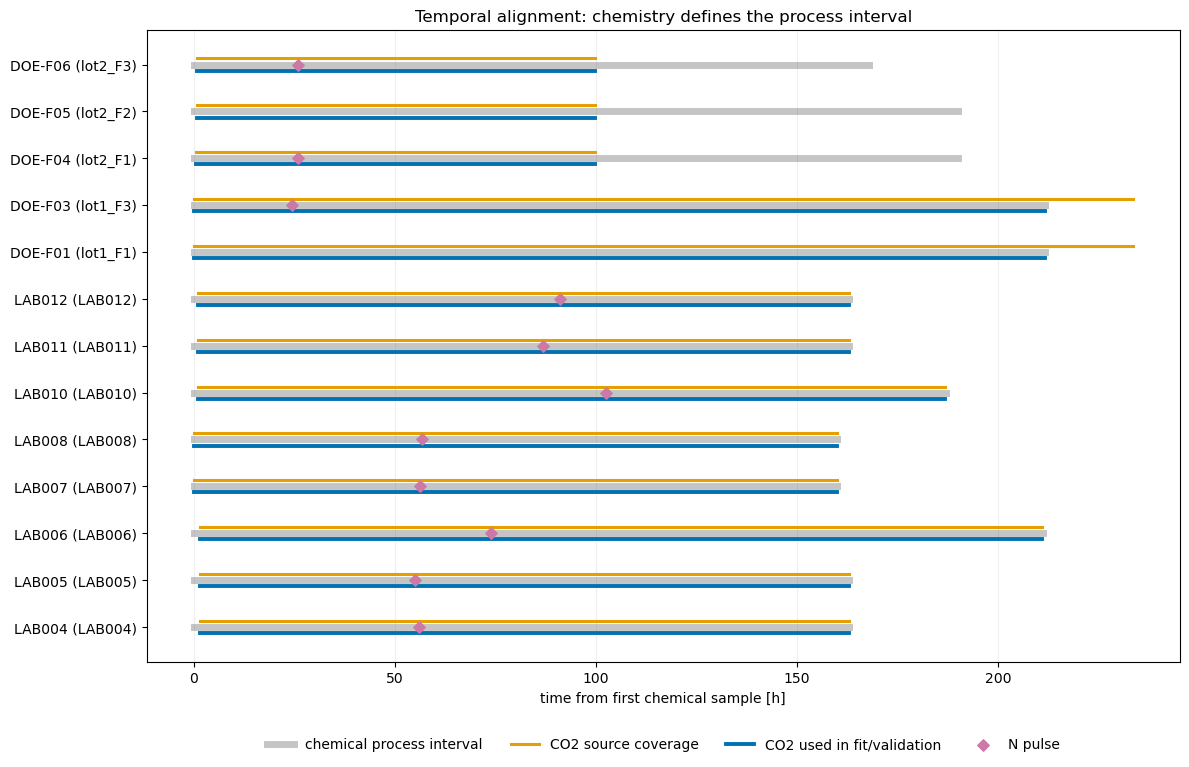

In [2]:
result = analysis.run_analysis(n_starts=5, max_nfev=300, seed=20260812)

display(result["exclusions"])
display(result["inventory"][[
    "matrix", "experiment_code", "batch", "lot", "calibratable", "split",
    "acquisition_channel", "sensor_id", "sensor_zero_offset_sccm",
    "n_co2_hourly", "chemistry_first_h", "chemistry_last_h", "co2_first_h",
    "co2_last_h", "co2_peak_g_l_h", "median_setpoint_c",
    "n_artifacts_replaced", "n_left_censored_hourly", "note"
]])
display(result["natural_nutrient_pulses"][[
    "batch", "calendar_t_h", "density_crossing_t_h", "density_bracket_width_h",
    "model_pulse_time_h", "timing_source", "amount_N_kg_m3",
    "calendar_product", "calendar_dose", "excluded_from_co2_analysis"
]])
fig = analysis.plot_process_timeline_alignment(
    result["inventory"], result["nutrient_pulses"], save=False
)
plt.show()

La separación se hace por fermentación completa. Los pulsos LAB aportan 0.14 kg N m⁻³; el pulso inicial se ignora porque el YAN inicial ya está en t=0. En todos los LAB con cruce disponible, el tiempo del pulso se obtiene por interpolación del cruce de densidad 1040 g/L. Un bracket químico >24 h se conserva, pero se etiqueta como incertidumbre de tiempo. En DOE-F0X se usa el tiempo de proceso existente, sin recalcularlo por densidad ni calendario.

## Filtrado y sensibilidad del sensor

,matrix,experiment_code,batch,acquisition_channel,sensor_id,sensor_zero_offset_sccm,sensor_zero_offset_g_l_h,median_setpoint_c,n_artifacts_replaced,n_sampling_window_transients,n_other_short_transients,negative_signed_fraction,n_left_censored_hourly,n_cold_low_sensitivity_hourly,smoothing_roughness_ratio,smoothing_integral_ratio,smoothing_peak_ratio
0,natural,LAB004,LAB004,F1,1,0.00000,0.000000,18.0,19,19,0,0.102911,65,0,0.304945,1.009568,0.915117
1,natural,LAB005,LAB005,F2,2,0.62066,0.025099,18.0,1,1,0,0.000000,43,0,0.219792,1.004438,0.988852
2,natural,LAB006,LAB006,F3,3,0.52838,0.021367,16.0,2,2,0,0.000000,71,0,0.263213,0.995662,0.962957
3,natural,LAB007,LAB007,F1,1,0.00000,0.000000,18.0,18,15,3,0.046875,60,0,0.403619,1.001061,0.889022
4,natural,LAB008,LAB008,F2,2,0.78048,0.031562,18.0,17,15,2,0.000000,47,0,0.416879,1.005046,0.863164
5,natural,LAB010,LAB010,F1,1,0.00000,0.000000,15.0,0,0,0,0.037273,101,100,0.379791,0.997475,0.993794
6,natural,LAB011,LAB011,F2,2,0.98992,0.040032,21.0,0,0,0,0.000000,85,45,0.416713,0.997368,0.988019
7,natural,LAB012,LAB012,F3,3,0.83948,0.033948,18.0,1,1,0,0.000000,63,52,0.460909,0.999966,0.976676
8,synthetic,DOE-F01,lot1_F1,F1,1,0.03998,0.002120,18.0,51,51,0,0.010236,35,0,0.167762,1.000070,0.880775
9,synthetic,DOE-F03,lot1_F3,F3,3,1.05890,0.056159,20.0,26,26,0,0.000000,57,0,0.208076,1.013734,0.992073


,matrix,batch,experiment_code,lot,acquisition_channel,sensor_id,sensor_assignment_source,zero_method,zero_window_h,zero_quantile,n_zero_candidates,initial_native_q10_sccm,estimated_zero_offset_sccm,estimated_zero_offset_g_l_h,initial_native_median_sccm,initial_corrected_q10_sccm,initial_corrected_median_sccm,sccm_conversion
0,natural,LAB004,LAB004,natural_2026,F1,1,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,-0.00042,0.00000,0.000000,0.00000,-4.200000e-04,0.00000,SCCM_CORRECTED
1,natural,LAB005,LAB005,natural_2026,F2,2,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.62066,0.62066,0.025099,0.72450,4.456071e-17,0.10384,SCCM_CORRECTED
2,natural,LAB006,LAB006,natural_2026,F3,3,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.52838,0.52838,0.021367,0.58710,4.453360e-17,0.05872,SCCM_CORRECTED
3,natural,LAB007,LAB007,natural_2026,F1,1,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,-0.00038,0.00000,0.000000,0.00010,-3.800000e-04,0.00010,SCCM_CORRECTED
4,natural,LAB008,LAB008,natural_2026,F2,2,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.78048,0.78048,0.031562,0.93975,2.320193e-17,0.15927,SCCM_CORRECTED
5,natural,LAB010,LAB010,natural_2026,F1,1,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,-0.00492,0.00000,0.000000,0.00000,-4.920000e-03,0.00000,SCCM_CORRECTED
6,natural,LAB011,LAB011,natural_2026,F2,2,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.98992,0.98992,0.040032,1.00820,-2.218549e-17,0.01828,SCCM_CORRECTED
7,natural,LAB012,LAB012,natural_2026,F3,3,cyclic LAB assignment inferred from repository...,initial_12h_q10,12.0,0.1,73,0.83948,0.83948,0.033948,0.85040,2.228035e-17,0.01092,SCCM_CORRECTED
8,synthetic,lot1_F1,DOE-F01,MBDOE_lot1,F1,1,explicit DOE mapping; DOE-F06 label 6 is acqui...,initial_12h_q10,12.0,0.1,73,0.03998,0.03998,0.001658,0.15745,-8.673617e-19,0.11747,SCCM_CORRECTED
9,synthetic,lot1_F3,DOE-F03,MBDOE_lot1,F3,3,explicit DOE mapping; DOE-F06 label 6 is acqui...,initial_12h_q10,12.0,0.1,73,1.05890,1.05890,0.043919,1.20635,9.367507e-17,0.14745,SCCM_CORRECTED


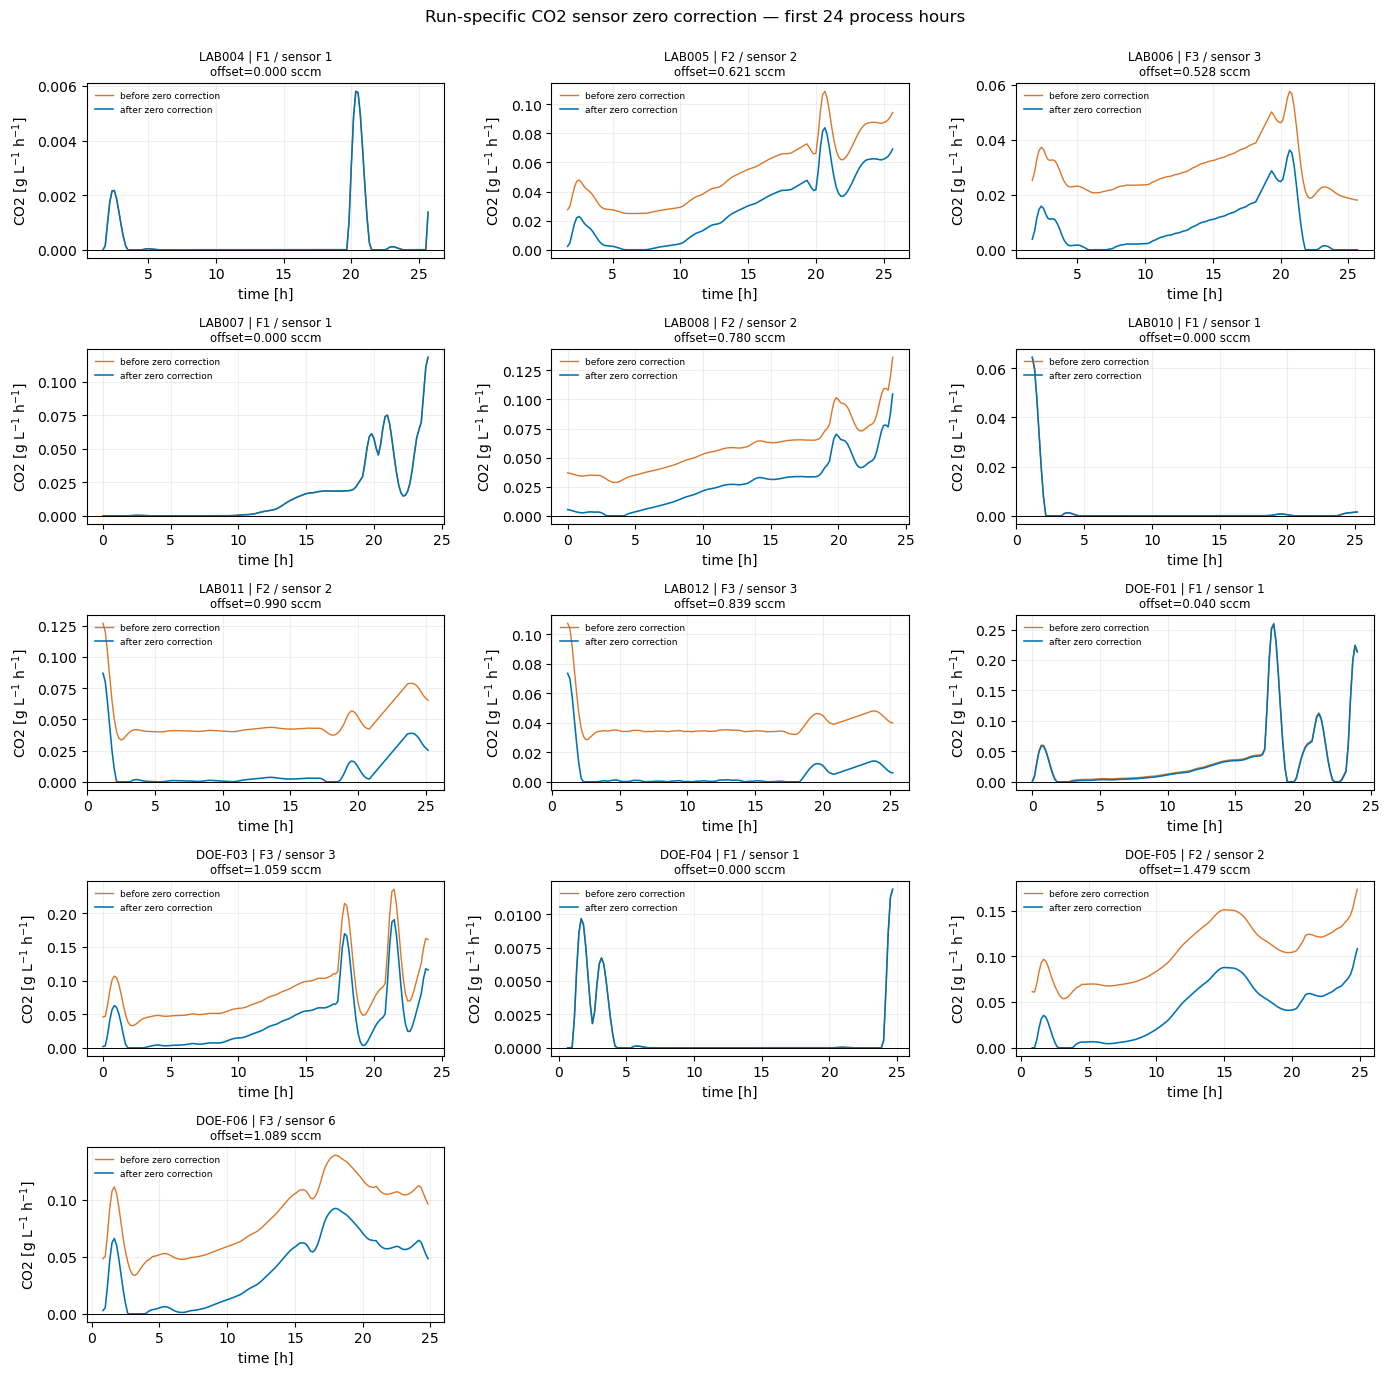

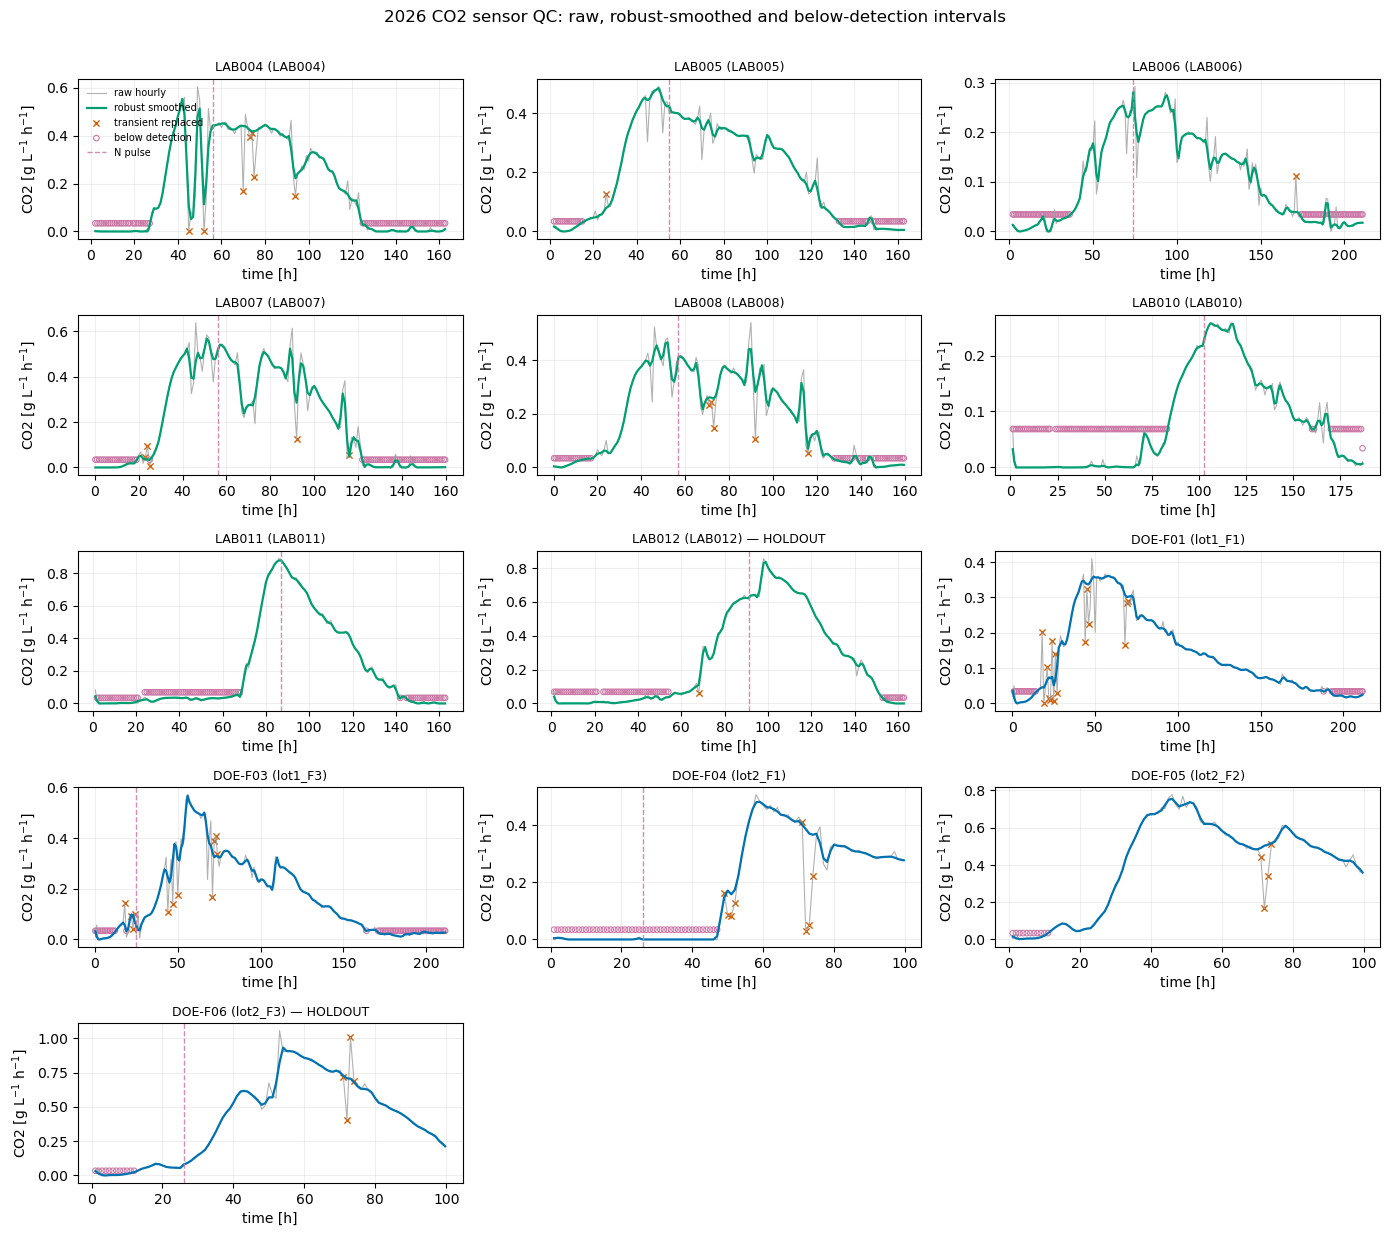

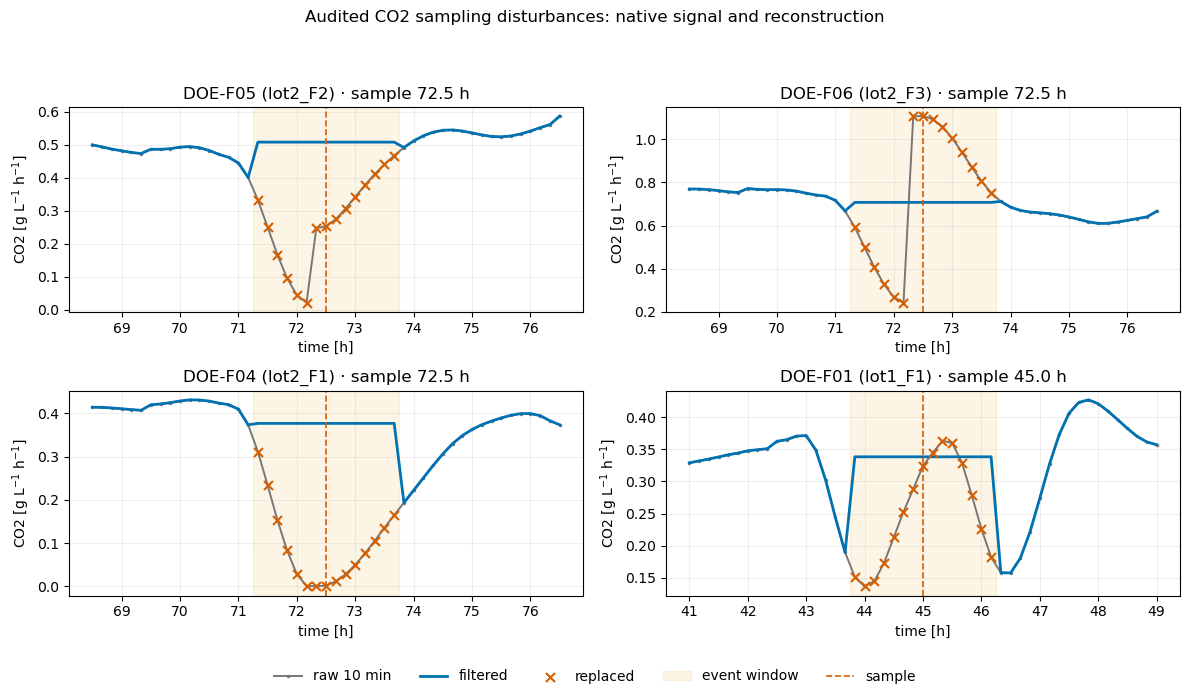

In [3]:
display(result["qc_summary"][[
    "matrix", "experiment_code", "batch", "acquisition_channel", "sensor_id",
    "sensor_zero_offset_sccm", "sensor_zero_offset_g_l_h", "median_setpoint_c",
    "n_artifacts_replaced", "n_sampling_window_transients",
    "n_other_short_transients", "negative_signed_fraction",
    "n_left_censored_hourly", "n_cold_low_sensitivity_hourly",
    "smoothing_roughness_ratio", "smoothing_integral_ratio", "smoothing_peak_ratio"
]])
display(result["sensor_zero_offsets"])
fig = analysis.plot_sensor_zero_correction(
    result["sensor_qc"], result["sensor_zero_offsets"], save=False
)
plt.show()
fig = analysis.plot_data_overview(
    result["observations"], result["nutrient_pulses"], save=False
)
plt.show()
fig = analysis.plot_sensor_filter_examples(
    result["sensor_qc"], result["sampling_schedule"],
    result["nutrient_pulses"], save=False
)
plt.show()

El primer gráfico comprueba la corrección de cero antes de cualquier reconstrucción. El offset se estima por corrida porque los canales muestran deriva entre campañas. Luego, las excursiones asociadas a muestreo se reconstruyen sólo cuando el evento completo está respaldado por niveles pre/post consistentes; se aplica mediana robusta de 3 h y Savitzky–Golay cuadrático de 5 h. Los puntos bajo el umbral local aportan una penalización unilateral si el modelo excede el límite.

## Temperatura y evidencia química de activación

,matrix,batch,temperature_used_min_c,temperature_used_mean_c,temperature_used_max_c,chemical_activity_lower_h,chemical_activity_upper_h,chemical_activity_center_h,initial_o2_saturation_base_mg_l,base_qprod_peak_g_l_h,csat_base_min_g_l,csat_base_max_g_l
0,natural,LAB004,17.7,19.266845,21.4,19.0,26.000000,22.500000,7.648403,0.358080,1.528572,1.957059
1,natural,LAB005,18.0,19.413936,21.4,0.0,19.000000,9.500000,7.497196,0.383042,1.490154,1.934773
2,natural,LAB006,16.0,17.030296,18.4,0.0,19.000000,9.500000,7.929510,0.288407,1.595673,2.090212
3,natural,LAB007,17.4,19.241498,21.1,0.0,16.000000,8.000000,7.497524,0.367365,1.510227,2.044642
4,natural,LAB008,17.4,19.195164,21.1,0.0,16.000000,8.000000,7.542804,0.380276,1.505889,1.873646
5,natural,LAB010,14.9,15.442991,16.5,0.0,72.000000,36.000000,8.146563,0.354771,1.665073,2.256914
6,natural,LAB011,14.9,18.842113,21.4,19.0,67.000000,43.000000,7.605382,0.433712,1.523275,2.076625
7,natural,LAB012,15.0,18.390505,21.2,0.0,48.000000,24.000000,8.150655,0.361827,1.662902,1.984255
8,synthetic,lot1_F1,17.6,18.107438,18.7,0.0,17.000000,8.500000,7.043979,0.407275,1.338996,2.012567
9,synthetic,lot1_F3,16.6,20.039876,23.0,0.0,17.000000,8.500000,7.792047,0.318327,1.507055,1.907763


,matrix,batch,experiment_code,n_temperature_comparisons,model_minus_sensor_bias_c,model_sensor_mae_c,model_sensor_rmse_c,model_sensor_max_abs_c
0,natural,LAB004,LAB004,162,0.006121,0.098508,0.142957,0.466667
1,natural,LAB005,LAB005,162,0.001800,0.038632,0.066050,0.250000
2,natural,LAB006,LAB006,209,0.022089,0.075518,0.131357,0.616667
3,natural,LAB007,LAB007,161,-0.005771,0.107531,0.259512,2.133333
4,natural,LAB008,LAB008,161,0.002277,0.058799,0.147161,1.500000
5,natural,LAB010,LAB010,184,0.017346,0.063089,0.095622,0.333333
6,natural,LAB011,LAB011,160,0.015964,0.081172,0.193215,1.866667
7,natural,LAB012,LAB012,160,0.019010,0.066146,0.148282,1.300000
8,synthetic,lot1_F1,DOE-F01,213,0.015258,0.261268,0.330510,0.800000
9,synthetic,lot1_F3,DOE-F03,213,-0.014554,0.093427,0.164445,0.700000


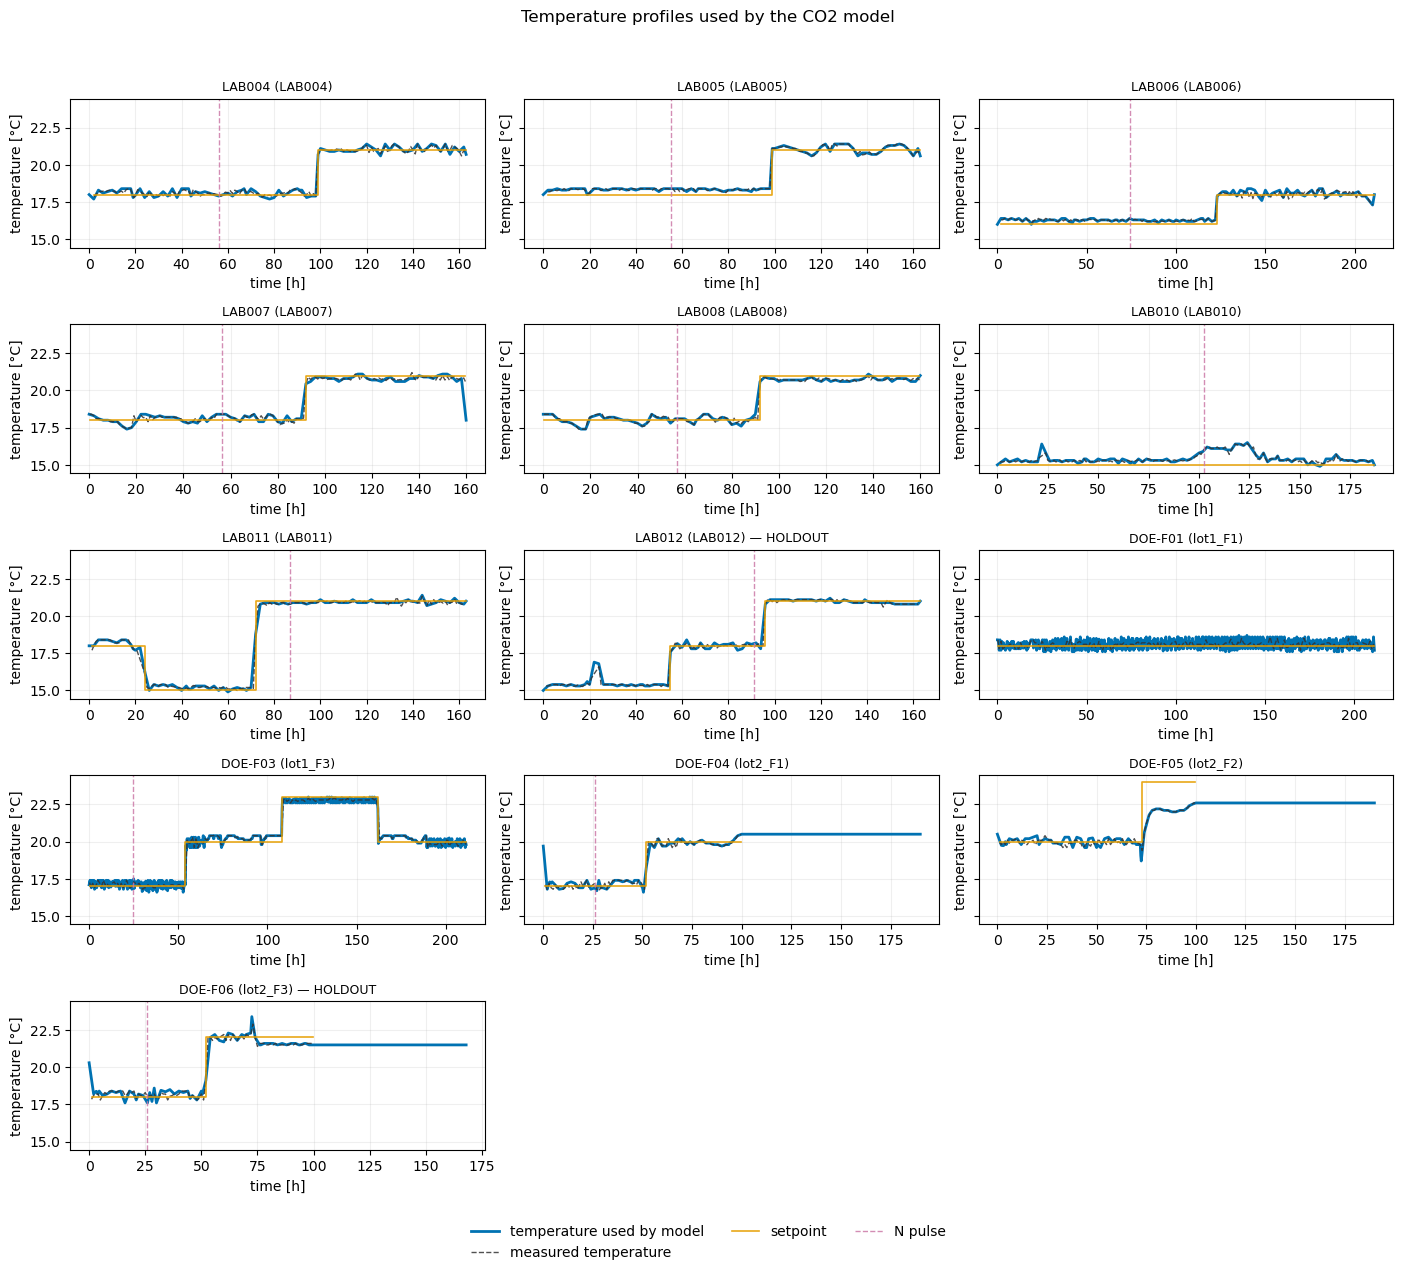

In [4]:
display(result["driver_diagnostics"][[
    "matrix", "batch", "temperature_used_min_c", "temperature_used_mean_c",
    "temperature_used_max_c", "chemical_activity_lower_h",
    "chemical_activity_upper_h", "chemical_activity_center_h",
    "initial_o2_saturation_base_mg_l", "base_qprod_peak_g_l_h",
    "csat_base_min_g_l", "csat_base_max_g_l"
]])
display(result["temperature_alignment"])
fig = analysis.plot_temperature_profiles(
    result["observations"], result["temperature_inputs"],
    result["nutrient_pulses"], save=False
)
plt.show()

La temperatura medida/reconstruida entra tanto a los drivers cinéticos como a la solubilidad de CO₂; el setpoint queda como referencia. La tabla permite verificar, lote por lote, el intervalo químico que condiciona el encendido de la fuente.

## Auditoría obligatoria de theta y SCCM

Esta celda se ejecuta después de construir los drivers; si cualquiera de los tres CSV no contiene
exactamente los 17 parámetros esperados, el runner falla antes de la primera simulación. La tabla de
reconstrucción identifica las seis filas que históricamente provenían de `DEFAULT_THETA`.

In [5]:
display(result["theta_validation_summary"])
display(result["theta_historical_audit"])
print("SCCM_CORRECTED [g/L/h/SCCM]:", result["manifest"]["sccm_conversion"]["factor_g_l_h_per_sccm_at_2L"])
print("Historical baseline reproduced:")
display(result["historical_reproduction_audit"])

,theta_label,csv_path,parameter_count,expected_count,all_17_present,sha256,simulation_use
0,natural,laboratory_2026/results/estimability_historica...,17,17,True,3876c53d0b4dc6f4126ffb4f8e0999a8455c90f283c345...,target natural batches
1,synthetic,laboratory_2026/results/estimability_historica...,17,17,True,009200460549b461dd46bf31b5d4aded36b2d99eed53c5...,target synthetic batches
2,joint,shared/results/new_must_glycerol_overnight_val...,17,17,True,146185f5d070c58b309a4b8ab492848a3326e243509c28...,validated reference only; original cross-matri...


,matrix,parameter,historical_load_mode,historical_value,complete_theta_value,absolute_change,historical_csv
0,natural,mu0,serialized_csv,0.078728,0.078728,0.000000,laboratory_2026/results/estimability_historica...
1,natural,sN,DEFAULT_THETA_fallback,18.000000,8.751446,-9.248554,laboratory_2026/results/estimability_historica...
2,natural,qN,serialized_csv,0.021080,0.021080,0.000000,laboratory_2026/results/estimability_historica...
3,natural,qXG,DEFAULT_THETA_fallback,0.112500,0.081491,-0.031009,laboratory_2026/results/estimability_historica...
4,natural,qXF,DEFAULT_THETA_fallback,0.112500,0.070933,-0.041567,laboratory_2026/results/estimability_historica...
5,natural,betaG0,serialized_csv,0.428878,0.428878,0.000000,laboratory_2026/results/estimability_historica...
6,natural,sG,DEFAULT_THETA_fallback,0.030000,0.097455,0.067455,laboratory_2026/results/estimability_historica...
7,natural,betaF0,serialized_csv,3.440399,3.440399,0.000000,laboratory_2026/results/estimability_historica...
8,natural,sF,DEFAULT_THETA_fallback,0.030000,0.178295,0.148295,laboratory_2026/results/estimability_historica...
9,natural,qEG,serialized_csv,1.712807,1.712807,0.000000,laboratory_2026/results/estimability_historica...


SCCM_CORRECTED [g/L/h/SCCM]: 0.0404391928807947
Historical baseline reproduced:


,quantity,n_rows,max_absolute_difference,mean_absolute_difference
0,observed_g_l_h,4178,0.000000e+00,0.000000e+00
1,predicted_g_l_h,4178,5.551115e-16,3.924626e-17
2,raw_model_qgas_g_l_h,4178,3.053113e-16,3.825356e-17


## Comparación explícita A/B/C

A→B cuantifica solo el reemplazo del theta. B→C cuantifica la readaptación de la capa CO₂. A→C es
el efecto final. La descomposición escala/forma ajusta únicamente un multiplicador diagnóstico entre
dos curvas ya calculadas; no modifica B ni constituye un refit. Un valor alto de la fracción explicada
por escala indica cambio mayormente multiplicativo.

,state,matrix,wsse_equal_batch_fixed_co2,n_residuals,matrix_gain,co2_refitted
0,A_historical,synthetic,19.515601,632,1.459910,False
1,A_historical,natural,27.952095,1216,2.139011,False
2,A_historical,all,47.467696,1848,NaN,False
3,B_full_theta_no_refit,synthetic,27.810253,632,1.459910,False
4,B_full_theta_no_refit,natural,54.472866,1216,2.139011,False
5,B_full_theta_no_refit,all,82.283119,1848,NaN,False
6,C_full_theta_refit,synthetic,18.908940,632,1.149648,True
7,C_full_theta_refit,natural,29.341781,1216,1.542283,True
8,C_full_theta_refit,all,48.250721,1848,NaN,True


,transition,left_state,right_state,calibration_matrix,parameter,left_estimate,right_estimate,absolute_change,percent_change,left_active_bound,right_active_bound
0,A_to_B,A_historical,B_full_theta_no_refit,synthetic,kCO2_release_h,3.883746,3.883746,0.000000e+00,0.000000e+00,False,False
1,A_to_B,A_historical,B_full_theta_no_refit,synthetic,CO2sat_scale,0.425408,0.425408,0.000000e+00,0.000000e+00,False,False
2,A_to_B,A_historical,B_full_theta_no_refit,synthetic,O2_qmax_mg_gdw_h,0.150164,0.150164,0.000000e+00,0.000000e+00,True,True
3,A_to_B,A_historical,B_full_theta_no_refit,synthetic,O2_initial_scale,0.380416,0.380416,0.000000e+00,0.000000e+00,False,False
4,A_to_B,A_historical,B_full_theta_no_refit,synthetic,pulse_t_rise_h,36.500023,36.500023,0.000000e+00,0.000000e+00,False,False
5,A_to_B,A_historical,B_full_theta_no_refit,synthetic,pulse_activity_gain,1.233338,1.233338,0.000000e+00,0.000000e+00,False,False
6,A_to_B,A_historical,B_full_theta_no_refit,synthetic,chem_activation_start_fraction,0.010004,0.010004,0.000000e+00,0.000000e+00,True,True
7,A_to_B,A_historical,B_full_theta_no_refit,synthetic,chem_activation_duration_fraction,0.350000,0.350000,0.000000e+00,0.000000e+00,True,True
8,A_to_B,A_historical,B_full_theta_no_refit,synthetic,matrix_gain,1.459910,1.459910,0.000000e+00,0.000000e+00,False,False
9,A_to_B,A_historical,B_full_theta_no_refit,natural,kCO2_release_h,0.424382,0.424382,0.000000e+00,0.000000e+00,False,False


,matrix,historical_matrix_gain,refit_matrix_gain,absolute_change,percent_change,direct_raw_integral_ratio_B_over_A,gain_ratio_C_over_A,gain_only_compensated_ratio_to_A,other_co2_layer_raw_ratio_C_over_B,final_scaled_integral_ratio_C_over_A,interpretation_guardrail
0,synthetic,1.459910,1.149648,-0.310262,-21.252106,1.279092,0.787479,1.007258,1.002452,1.009727,matrix_gain is an empirical observation/scale ...
1,natural,2.139011,1.542283,-0.596728,-27.897366,1.185122,0.721026,0.854505,1.039211,0.888011,matrix_gain is an empirical observation/scale ...


,state,model,calibration_matrix,target_matrix,batch,experiment_code,role,n,n_total,n_left_censored,rmse_g_l_h,mae_g_l_h,bias_g_l_h,nrmse_peak,correlation,r2,observed_peak_g_l_h,predicted_peak_g_l_h,observed_peak_time_h,predicted_peak_time_h,...,observed_onset_h,predicted_onset_h,onset_delay_h,visual_rise_low_threshold_g_l_h,visual_rise_high_threshold_g_l_h,observed_visual_rise_low_h,observed_visual_rise_high_h,observed_visual_rise_duration_h,predicted_first_emission_0p005_h,predicted_visual_rise_low_h,predicted_visual_rise_high_h,predicted_visual_rise_duration_h,visual_rise_duration_error_h,pulse_time_h,observed_postpulse_peak_h,predicted_postpulse_peak_h,observed_pulse_t_rise_h,predicted_pulse_t_rise_h,postpulse_peak_delay_h,scenario
0,A_historical,solubility_o2_nitrogen_boost_continuous_release,synthetic,natural,LAB012,LAB012,cross_holdout,98,161,63,0.262905,0.221831,-0.134862,0.314682,0.391021,-0.199708,0.835463,0.332797,99.0,58.0,...,65.156714,14.756717,-50.399997,0.017140,0.083942,37.845148,65.156714,27.311566,6.276060,9.600226,14.756717,5.156491,-22.155075,91.041739,99.0,102.0,7.958261,10.958261,3.0,cross_matrix_holdout
1,A_historical,solubility_o2_nitrogen_boost_continuous_release,natural,natural,LAB012,LAB012,internal_holdout,98,161,63,0.218546,0.186302,-0.142275,0.261587,0.776977,0.170979,0.835463,0.430035,99.0,88.0,...,65.156714,54.596062,-10.560652,0.017140,0.083942,37.845148,65.156714,27.311566,43.711819,47.633718,54.596062,6.962344,-20.349222,91.041739,99.0,92.0,7.958261,0.958261,-7.0,within_matrix_holdout
2,A_historical,solubility_o2_nitrogen_boost_continuous_release,natural,synthetic,lot2_F3,DOE-F06,cross_holdout,88,100,12,0.223794,0.197371,-0.197371,0.240241,0.963349,0.314353,0.931537,0.621052,54.0,56.0,...,27.509842,30.380292,2.870450,0.024555,0.098594,12.030648,27.509842,15.479194,23.365046,26.664162,30.380292,3.716130,-11.763064,26.000000,54.0,56.0,28.000000,30.000000,2.0,cross_matrix_holdout
3,A_historical,solubility_o2_nitrogen_boost_continuous_release,synthetic,synthetic,lot2_F3,DOE-F06,internal_holdout,88,100,12,0.167725,0.130063,-0.104597,0.180052,0.876565,0.614877,0.931537,0.788604,54.0,54.0,...,27.509842,36.311061,8.801219,0.024555,0.098594,12.030648,27.509842,15.479194,9.141964,20.012238,36.311061,16.298823,0.819629,26.000000,54.0,54.0,28.000000,28.000000,0.0,within_matrix_holdout
4,B_full_theta_no_refit,solubility_o2_nitrogen_boost_continuous_release,synthetic,natural,LAB012,LAB012,cross_holdout,98,161,63,0.335821,0.304067,-0.137711,0.401958,0.088301,-0.957462,0.835463,0.522447,99.0,62.0,...,65.156714,13.579615,-51.577099,0.017140,0.083942,37.845148,65.156714,27.311566,5.741412,8.735032,13.579615,4.844583,-22.466983,91.041739,99.0,97.0,7.958261,5.958261,-2.0,cross_matrix_holdout
5,B_full_theta_no_refit,solubility_o2_nitrogen_boost_continuous_release,natural,natural,LAB012,LAB012,internal_holdout,98,161,63,0.277885,0.247957,-0.098792,0.332612,0.455391,-0.340319,0.835463,0.694367,99.0,84.0,...,65.156714,52.120948,-13.035766,0.017140,0.083942,37.845148,65.156714,27.311566,42.864890,46.272071,52.120948,5.848877,-21.462689,91.041739,99.0,92.0,7.958261,0.958261,-7.0,within_matrix_holdout
6,B_full_theta_no_refit,solubility_o2_nitrogen_boost_continuous_release,natural,synthetic,lot2_F3,DOE-F06,cross_holdout,88,100,12,0.119524,0.103237,-0.103237,0.128308,0.974928,0.804424,0.931537,0.873465,54.0,56.0,...,27.509842,29.605333,2.095491,0.024555,0.098594,12.030648,27.509842,15.479194,23.012975,26.116792,29.605333,3.488541,-11.990653,26.000000,54.0,56.0,28.000000,30.000000,2.0,cross_matrix_holdout
7,B_full_theta_no_refit,solubility_o2_nitrogen_boost_continuous_release,synthetic,synthetic,lot2_F3,DOE-F06,internal_holdout,88,100,12,0.187509,0.163438,0.031197,0.201290,0.876038,0.518661,0.931537,1.129665,54.0,55.0,...,27.509842,35.054008,7.544166,0.024555,0.098594,12.030648,27.509842,15.479194,8.653681,16.321836,35.054008,18.732173,3.252979,26.000000,54.0,55.0,28.000000,29.000000,1.0,within_matrix_holdout
8,C_full_the

,transition,calibration_matrix,target_matrix,batch,experiment_code,role,best_multiplicative_scale_right_from_left,direct_prediction_rmse_g_l_h,shape_rmse_after_best_scale_g_l_h,fraction_squared_change_explained_by_scale,prediction_shape_correlation,integral_ratio_right_over_left,peak_ratio_right_over_left,peak_time_change_h
25,A_to_B,synthetic,synthetic,lot2_F3,DOE-F06,internal_holdout,1.399733,0.167979,0.029028,0.970138,0.997571,1.377660,1.432486,1.000000
20,A_to_B,synthetic,natural,LAB012,LAB012,cross_holdout,1.129163,0.154304,0.150290,0.051359,0.736814,1.066709,1.408680,37.916667
14,A_to_B,synthetic,natural,LAB005,LAB005,cross_context,1.219750,0.150798,0.136123,0.185160,0.797309,1.165712,1.579440,0.000000
19,A_to_B,synthetic,natural,LAB011,LAB011,cross_context,1.051904,0.146463,0.145903,0.007629,0.773875,0.943796,1.686524,0.000000
18,A_to_B,synthetic,natural,LAB010,LAB010,cross_context,1.111592,0.134557,0.131794,0.040657,0.808283,1.013299,1.357909,0.000000
13,A_to_B,synthetic,natural,LAB004,LAB004,cross_context,1.183436,0.133394,0.124979,0.122191,0.800095,1.120145,1.504195,-9.000000
16,A_to_B,synthetic,natural,LAB007,LAB007,cross_context,1.284087,0.131232,0.109064,0.309310,0.839486,1.244887,1.660656,2.000000
17,A_to_B,synthetic,natural,LAB008,LAB008,cross_context,1.281728,0.131176,0.109175,0.307316,0.849425,1.238628,1.663016,0.000000
7,A_to_B,natural,natural,LAB012,LAB012,internal_holdout,1.276146,0.130136,0.112759,0.249223,0.904590,1.143502,1.614675,-4.000000
1,A_to_B,natural,natural,LAB005,LAB005,calibration,1.384736,0.128263,0.077799,0.632090,0.967485,1.270639,1.404641,0.000000


,state,matrix,n_residuals,n_shape_parameters,effective_rank,condition_number_log_parameter_jacobian,smallest_singular_value,largest_singular_value,residual_variance_scale,interpretation
0,A_historical,synthetic,632,8,8,2.924571e+07,2.660739e-07,7.781522,0.031275,ill_conditioned
1,A_historical,natural,1216,8,8,1.297731e+02,7.874208e-02,10.218605,0.023139,moderate_or_better
2,C_full_theta_refit,synthetic,632,8,8,9.076098e+10,3.373549e-08,3061.865826,0.030303,ill_conditioned
3,C_full_theta_refit,natural,1216,8,8,1.374952e+07,8.860414e-07,12.182643,0.024290,ill_conditioned


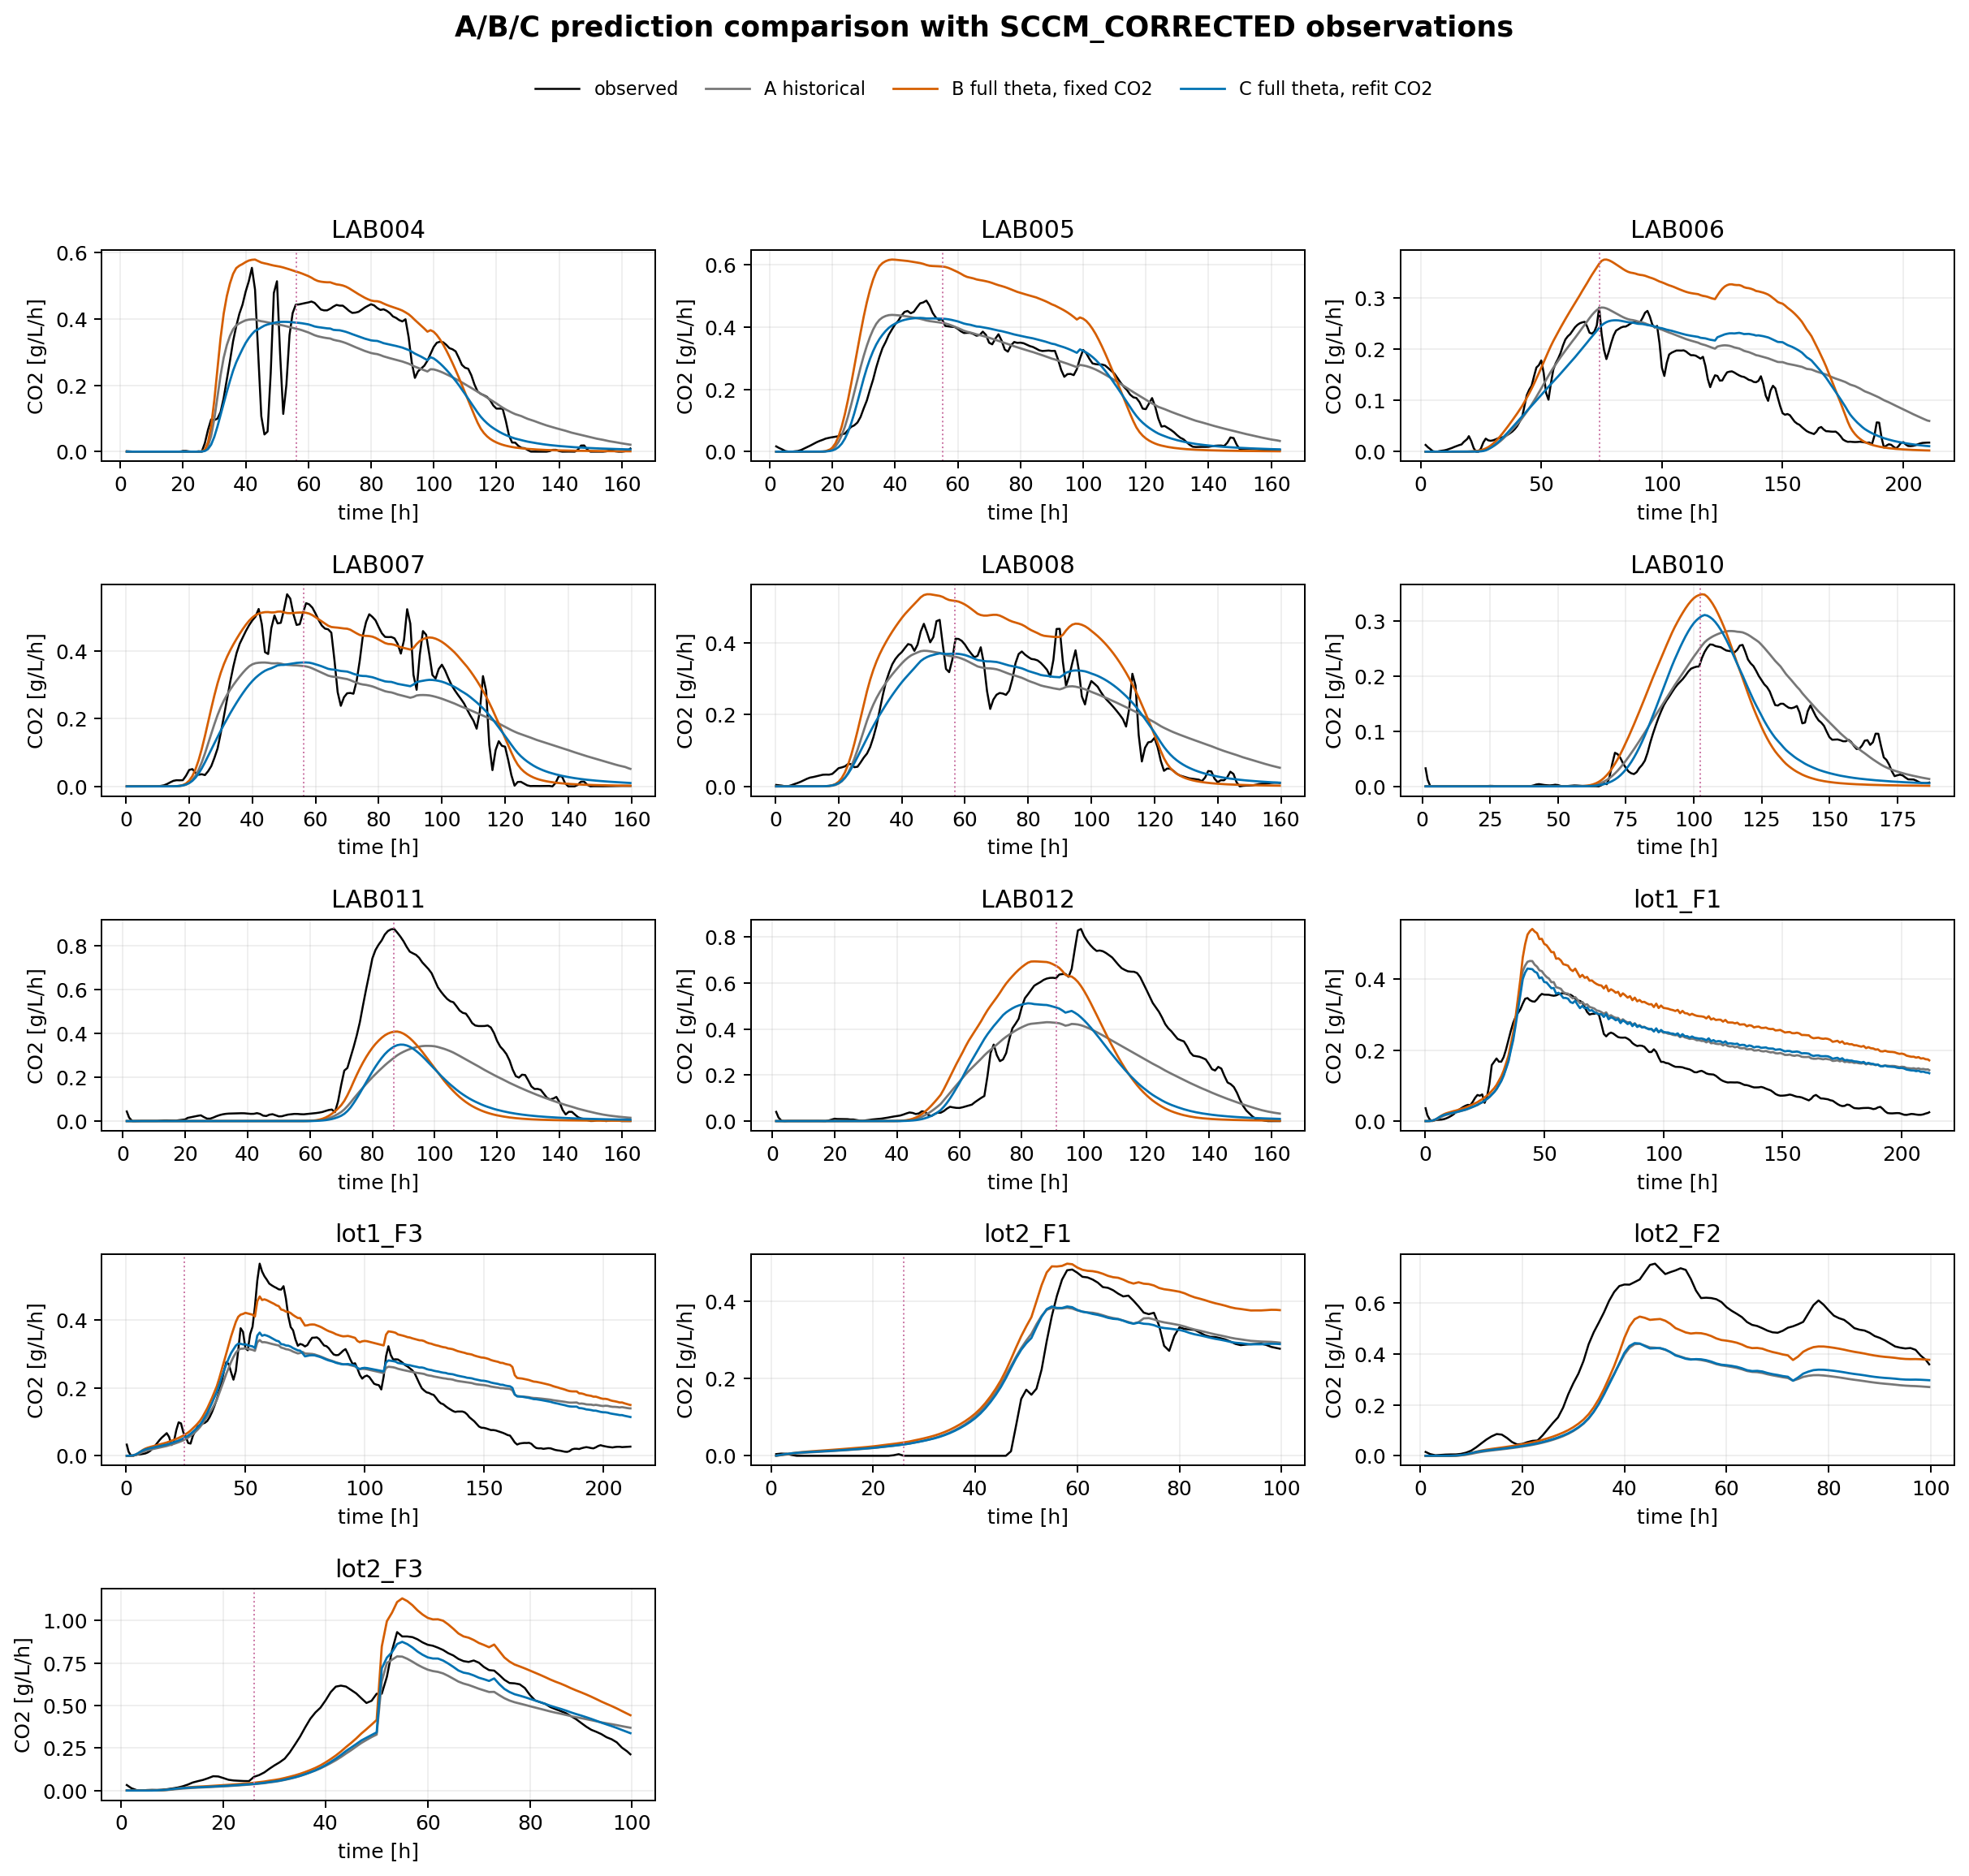

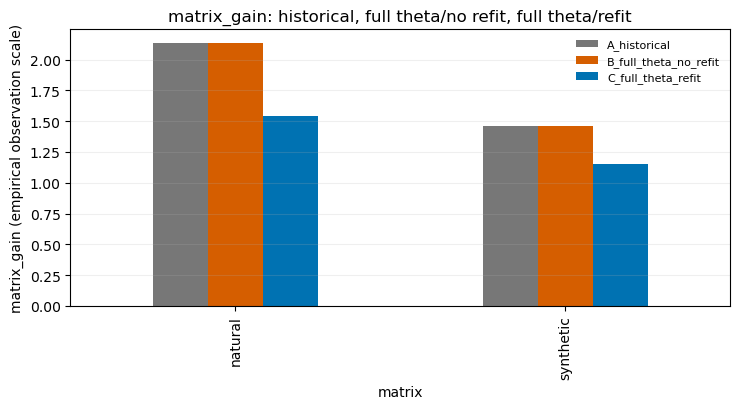

In [6]:
display(result["state_objectives"])
display(result["state_parameter_changes"])
display(result["matrix_gain_compensation"])
display(result["state_validation"])
display(
    result["pairwise_shape_scale"]
    .query("transition == 'A_to_B'")
    .sort_values("direct_prediction_rmse_g_l_h", ascending=False)
)
display(result["identifiability_state_comparison"])
fig = analysis.plot_three_state_overlays(result["state_predictions"], save=False)
plt.show()
fig = analysis.plot_matrix_gain_three_states(result["state_parameters"], save=False)
plt.show()

## Estado C — recalibración CO₂ por matriz con theta completo congelado

,calibration_matrix,parameter,estimate,lower_bound,upper_bound,active_bound,relative_bound_distance
0,synthetic,kCO2_release_h,6.118870,0.03,25.00,False,2.092799e-01
1,synthetic,CO2sat_scale,0.606169,0.35,2.50,False,2.793459e-01
2,synthetic,O2_qmax_mg_gdw_h,0.150032,0.15,6.00,True,5.856736e-05
3,synthetic,O2_initial_scale,0.359185,0.05,1.50,False,4.202587e-01
4,synthetic,pulse_t_rise_h,35.314587,1.00,72.00,False,1.665713e-01
5,synthetic,pulse_activity_gain,1.197615,0.25,4.00,False,4.349590e-01
6,synthetic,chem_activation_start_fraction,0.010000,0.01,0.95,True,3.507122e-09
7,synthetic,chem_activation_duration_fraction,0.350000,0.35,2.00,True,3.955875e-10
8,synthetic,matrix_gain,1.149648,0.10,20.00,False,4.609088e-01
9,natural,kCO2_release_h,0.289048,0.03,25.00,False,3.368399e-01


,matrix,success,nfev,wsse_equal_batch,kCO2_release_h,CO2sat_scale,O2_qmax_mg_gdw_h,O2_initial_scale,pulse_t_rise_h,pulse_activity_gain,chem_activation_start_fraction,chem_activation_duration_fraction,matrix_gain
0,natural,True,20,29.341781,0.289048,2.500000,3.051140,1.485664,64.304619,0.250000,0.76177,0.801185,1.542283
1,synthetic,True,44,18.908940,6.118870,0.606169,0.150032,0.359185,35.314587,1.197615,0.01000,0.350000,1.149648


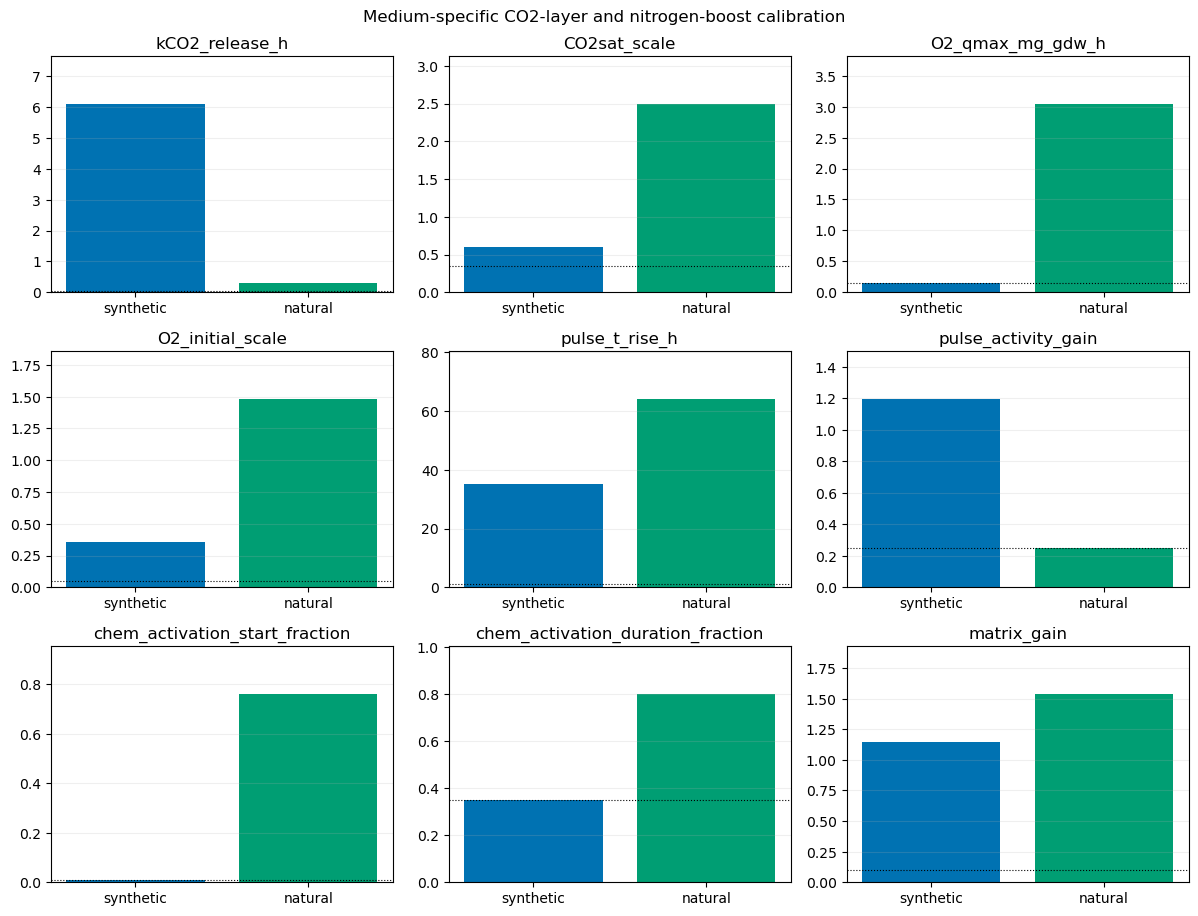

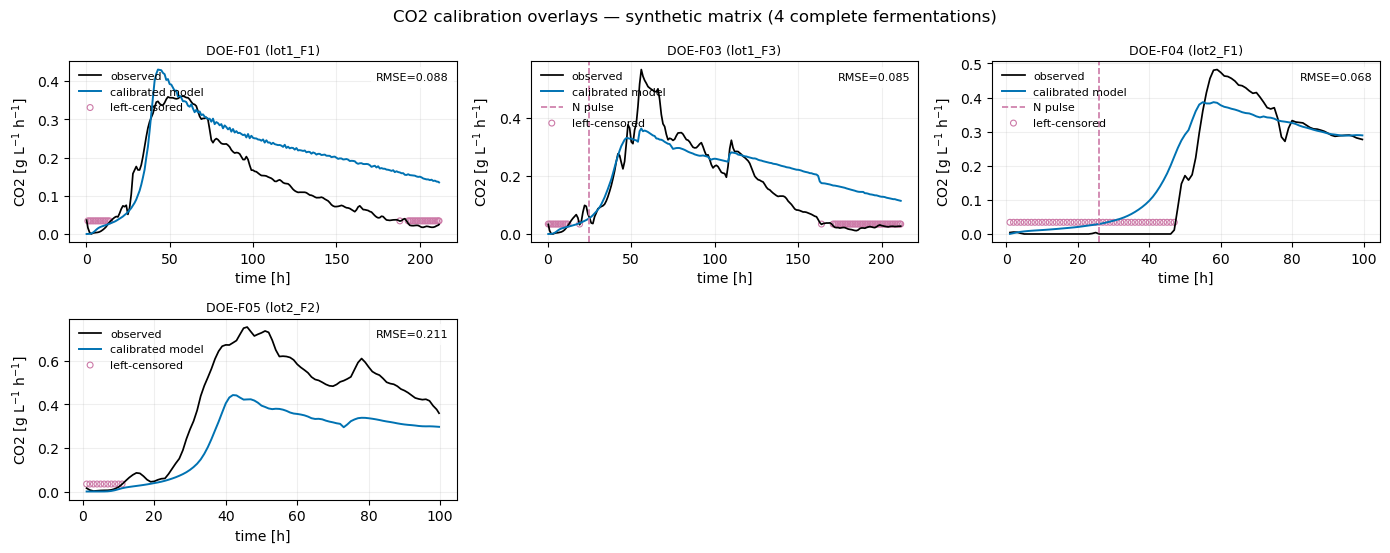

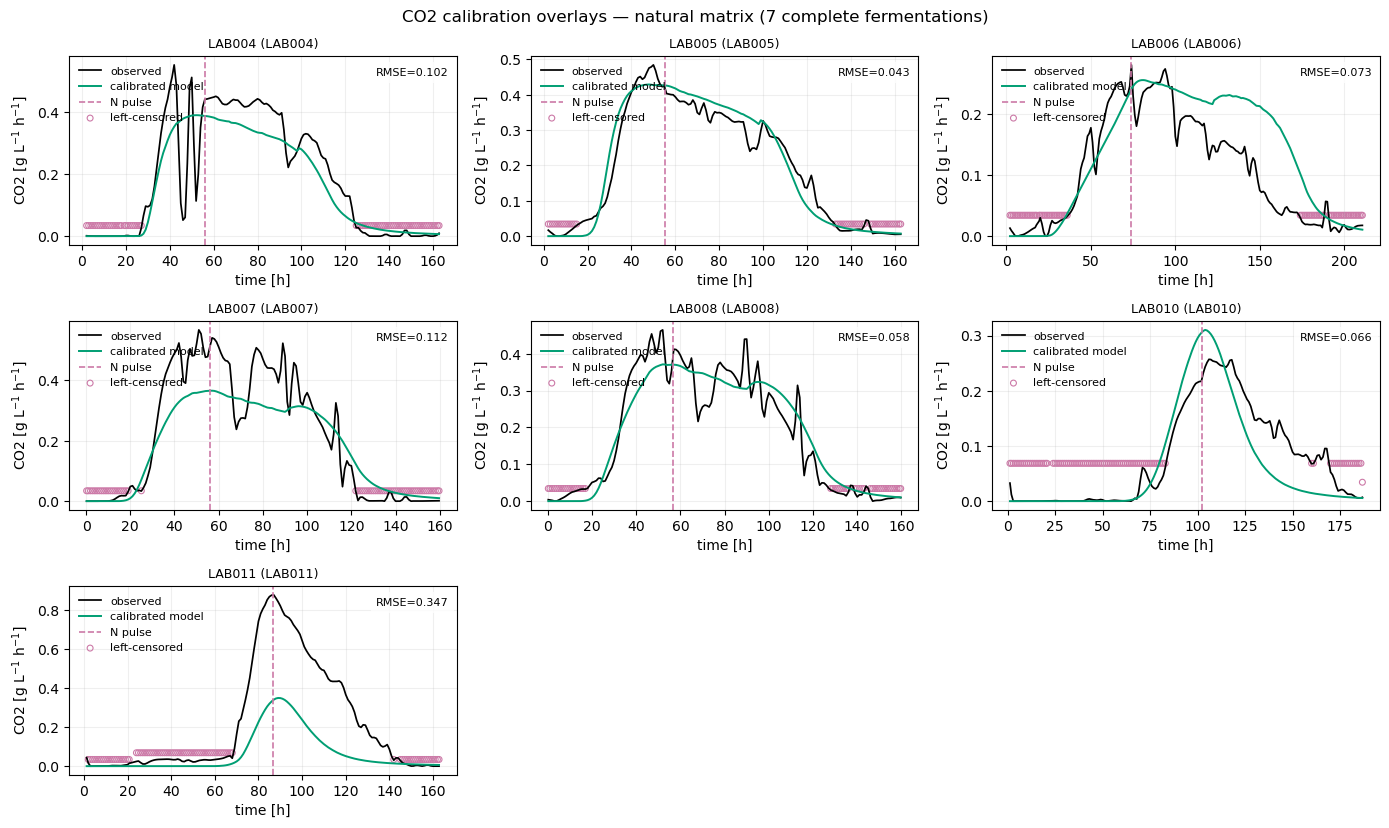

In [7]:
display(result["fit_parameters"])
best_starts = (
    result["fit_starts"].sort_values("wsse_equal_batch")
    .groupby("matrix", as_index=False).first()
)
display(best_starts[[
    "matrix", "success", "nfev", "wsse_equal_batch", "kCO2_release_h",
    "CO2sat_scale", "O2_qmax_mg_gdw_h", "O2_initial_scale",
    "pulse_t_rise_h", "pulse_activity_gain",
    "chem_activation_start_fraction", "chem_activation_duration_fraction",
    "matrix_gain"
]])
fig = analysis.plot_parameter_comparison(result["fit_parameters"], save=False)
plt.show()
for matrix in ("synthetic", "natural"):
    fig = analysis.plot_calibration_overlays(result["predictions"], matrix, save=False)
    plt.show()

`active_bound=True` indica que el dato sólo acota el parámetro en el borde permitido. Debe leerse como tensión estructural o falta de identificabilidad, no como una estimación interior resuelta. `chem_activation_start_fraction` ubica el inicio dentro del bracket químico y `chem_activation_duration_fraction` escala la duración por el ancho de ese bracket. `pulse_activity_gain=1` significa ausencia de modulación sobre la actividad preexistente; >1 es boost y <1 es atenuación.

En esta sección todos los estimates corresponden al estado C. Los estados A y B comparten exactamente los parámetros CO₂ históricos; B no ejecuta fitting.

## Estimabilidad de inicio y duración

,matrix,n_residuals,n_shape_parameters,effective_rank,condition_number_log_parameter_jacobian,smallest_singular_value,largest_singular_value,residual_variance_scale,interpretation
0,synthetic,632,8,8,9.076098e+10,3.373549e-08,3061.865826,0.030303,ill_conditioned
1,natural,1216,8,8,1.374952e+07,8.860414e-07,12.182643,0.024290,ill_conditioned


,matrix,parameter_1,parameter_2,local_log_parameter_correlation
126,natural,chem_activation_duration_fraction,chem_activation_start_fraction,-0.941152
123,natural,chem_activation_duration_fraction,O2_initial_scale,-0.121639
125,natural,chem_activation_duration_fraction,pulse_activity_gain,-0.111589
124,natural,chem_activation_duration_fraction,pulse_t_rise_h,0.019842
122,natural,chem_activation_duration_fraction,O2_qmax_mg_gdw_h,0.121625
120,natural,chem_activation_duration_fraction,kCO2_release_h,0.275031
121,natural,chem_activation_duration_fraction,CO2sat_scale,0.285925
127,natural,chem_activation_duration_fraction,chem_activation_duration_fraction,1.000000
119,natural,chem_activation_start_fraction,chem_activation_duration_fraction,-0.941152
113,natural,chem_activation_start_fraction,CO2sat_scale,-0.385699


,matrix,parameter,full_fit_estimate,loo_min,loo_median,loo_max,loo_range,loo_relative_range_to_full,n_omissions,n_at_lower_bound,n_at_upper_bound
0,natural,chem_activation_start_fraction,0.761770,0.599077,0.756516,0.810822,2.117456e-01,2.779653e-01,7,0,0
1,natural,chem_activation_duration_fraction,0.801185,0.736032,0.790626,0.845992,1.099599e-01,1.372466e-01,7,0,0
2,synthetic,chem_activation_start_fraction,0.010000,0.010000,0.010000,0.010000,1.687858e-11,1.687858e-09,4,4,0
3,synthetic,chem_activation_duration_fraction,0.350000,0.350000,0.350000,0.350000,3.516015e-11,1.004576e-10,4,4,0


,matrix,omitted_batch,success,nfev,chem_activation_start_fraction,chem_activation_duration_fraction
0,synthetic,lot1_F1,True,29,0.010000,0.350000
1,synthetic,lot1_F3,True,31,0.010000,0.350000
2,synthetic,lot2_F1,True,25,0.010000,0.350000
3,synthetic,lot2_F2,True,28,0.010000,0.350000
4,natural,LAB004,True,14,0.762521,0.790626
5,natural,LAB005,True,18,0.776608,0.789763
6,natural,LAB006,True,28,0.740194,0.845992
7,natural,LAB007,True,29,0.748117,0.788890
8,natural,LAB008,True,31,0.756516,0.797478
9,natural,LAB010,True,31,0.599077,0.736032


,matrix,profiled_parameter,fixed_value,wsse_equal_batch,success,nfev,full_fit_estimate,delta_wsse,relative_wsse_increase
0,natural,chem_activation_duration_fraction,0.350000,29.727155,True,40,0.801185,3.853742e-01,1.313397e-02
1,natural,chem_activation_duration_fraction,0.467981,29.547081,True,37,0.801185,2.052994e-01,6.996829e-03
2,natural,chem_activation_duration_fraction,0.625732,29.482878,True,16,0.801185,1.410973e-01,4.808749e-03
3,natural,chem_activation_duration_fraction,0.801185,29.341781,True,2,0.801185,0.000000e+00,0.000000e+00
4,natural,chem_activation_duration_fraction,0.836660,29.347248,True,14,0.801185,5.466973e-03,1.863204e-04
5,natural,chem_activation_duration_fraction,1.118689,29.679631,True,31,0.801185,3.378496e-01,1.151428e-02
6,natural,chem_activation_duration_fraction,1.495787,30.902488,True,20,0.801185,1.560707e+00,5.319060e-02
7,natural,chem_activation_duration_fraction,2.000000,33.184539,True,17,0.801185,3.842758e+00,1.309654e-01
8,natural,chem_activation_start_fraction,0.010000,40.100382,True,23,0.761770,1.082122e+01,3.695880e-01
9,natural,chem_activation_start_fraction,0.166667,34.048206,True,33,0.761770,4.769049e+00,1.628820e-01


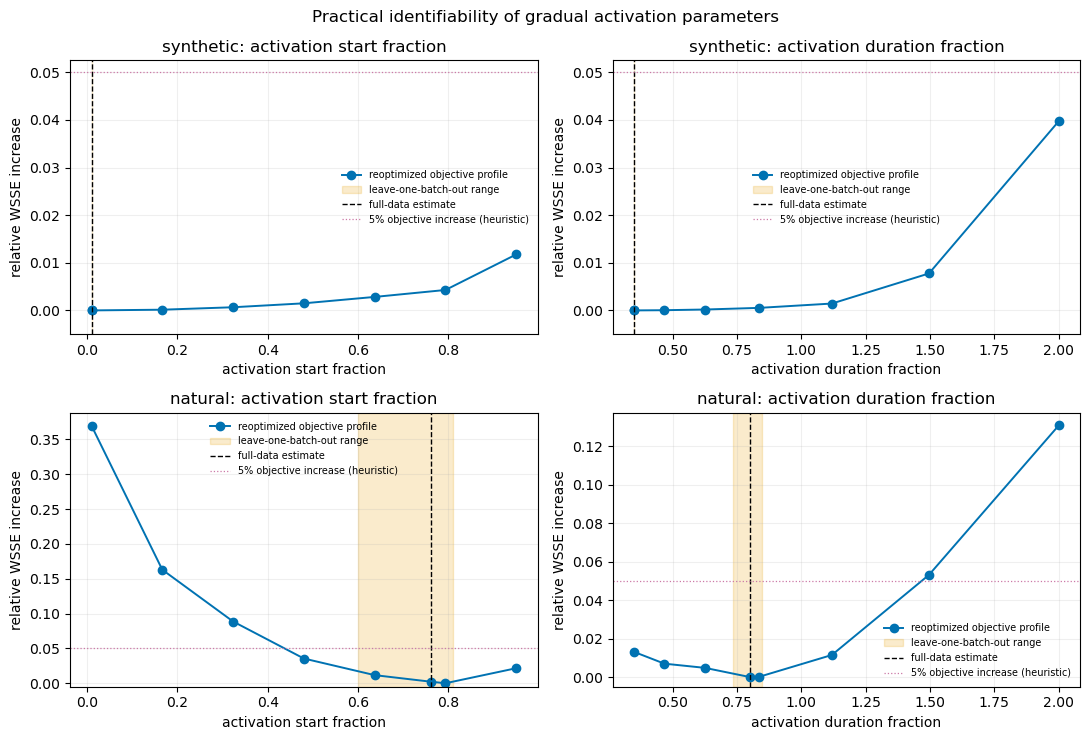

In [8]:
display(result["jacobian_identifiability"])
display(
    result["local_parameter_correlations"].query(
        "parameter_1 in ['chem_activation_start_fraction', 'chem_activation_duration_fraction']"
    )[["matrix", "parameter_1", "parameter_2", "local_log_parameter_correlation"]]
    .sort_values(["matrix", "parameter_1", "local_log_parameter_correlation"])
)
display(result["loo_activation_summary"])
display(result["loo_activation_estimates"][[
    "matrix", "omitted_batch", "success", "nfev",
    "chem_activation_start_fraction", "chem_activation_duration_fraction"
]])
display(result["activation_profiles"])
fig = analysis.plot_activation_identifiability(
    result["activation_profiles"], result["loo_activation_summary"], save=False
)
plt.show()

El Jacobiano evalúa sensibilidad local en log-parámetros; un número de condición alto indica direcciones compensables. Los perfiles fijan uno de los dos parámetros y reoptimizan todos los demás. La franja naranjo muestra cuánto cambia la estimación al retirar una fermentación completa. La línea horizontal de 5 % es sólo un umbral descriptivo de sensibilidad del objetivo, no un intervalo de confianza de verosimilitud.

La identificabilidad se compara entre A y C, ambos óptimos de calibración. No se atribuye identificabilidad a B porque deliberadamente no es un óptimo.

## ¿Se corrigió la cola inicial?

,target_matrix,experiment_code,batch,median_setpoint_c,cold_operation,chemical_activity_lower_h,chemical_activity_upper_h,source_10pct_peak_onset_h,o2_below_anaerobic_halfpoint_h,observed_onset_h,predicted_onset_h,onset_delay_h,O2_qmax_mg_gdw_h,O2_initial_scale,n_pulse_time_h,pulse_t_rise_h,pulse_activity_gain,chem_activation_start_fraction,chem_activation_duration_fraction,pulse_utilization_complete_h,observed_postpulse_peak_h,predicted_postpulse_peak_h,postpulse_peak_delay_h
8,synthetic,DOE-F01,lot1_F1,18.0,False,0.0,17.000000,20.00,36.25,16.399541,20.334196,3.934655,0.150032,0.359185,NaN,35.314587,1.197615,0.01000,0.350000,NaN,NaN,NaN,NaN
9,synthetic,DOE-F03,lot1_F3,20.0,False,0.0,17.000000,17.50,37.75,20.640551,26.640831,6.000280,0.150032,0.359185,24.500000,35.314587,1.197615,0.01000,0.350000,59.814587,56.0,56.0,0.0
10,synthetic,DOE-F04,lot2_F1,17.0,False,0.0,3.174722,28.75,44.75,47.547195,32.802113,-14.745083,0.150032,0.359185,26.000000,35.314587,1.197615,0.01000,0.350000,61.314587,59.0,58.0,-1.0
11,synthetic,DOE-F05,lot2_F2,20.0,False,4.5,21.000000,20.75,35.75,24.057329,28.225744,4.168415,0.150032,0.359185,NaN,35.314587,1.197615,0.01000,0.350000,NaN,NaN,NaN,NaN
12,synthetic,DOE-F06,lot2_F3,18.0,False,4.5,21.000000,34.25,42.00,27.509842,36.215465,8.705623,0.150032,0.359185,26.000000,35.314587,1.197615,0.01000,0.350000,61.314587,54.0,55.0,1.0
13,natural,LAB004,LAB004,18.0,False,19.0,26.000000,25.75,8.25,27.735273,30.350424,2.615151,3.051140,1.485664,56.091667,64.304619,0.250000,0.76177,0.801185,120.396286,61.0,57.0,-4.0
14,natural,LAB005,LAB005,18.0,False,0.0,19.000000,18.00,6.50,22.576040,24.531517,1.955477,3.051140,1.485664,55.086614,64.304619,0.250000,0.76177,0.801185,119.391233,56.0,56.0,0.0
15,natural,LAB006,LAB006,16.0,False,0.0,19.000000,25.25,25.50,36.543760,35.523228,-1.020532,3.051140,1.485664,74.000000,64.304619,0.250000,0.76177,0.801185,138.304619,74.0,81.0,7.0
16,natural,LAB007,LAB007,18.0,False,0.0,16.000000,16.00,10.25,26.797300,24.191594,-2.605706,3.051140,1.485664,56.246154,64.304619,0.250000,0.76177,0.801185,120.550773,57.0,57.0,0.0
17,natural,LAB008,LAB008,18.0,False,0.0,16.000000,16.25,11.75,20.661926,24.185345,3.523418,3.051140,1.485664,56.750000,64.304619,0.250000,0.76177,0.801185,121.054619,90.0,57.0,-33.0


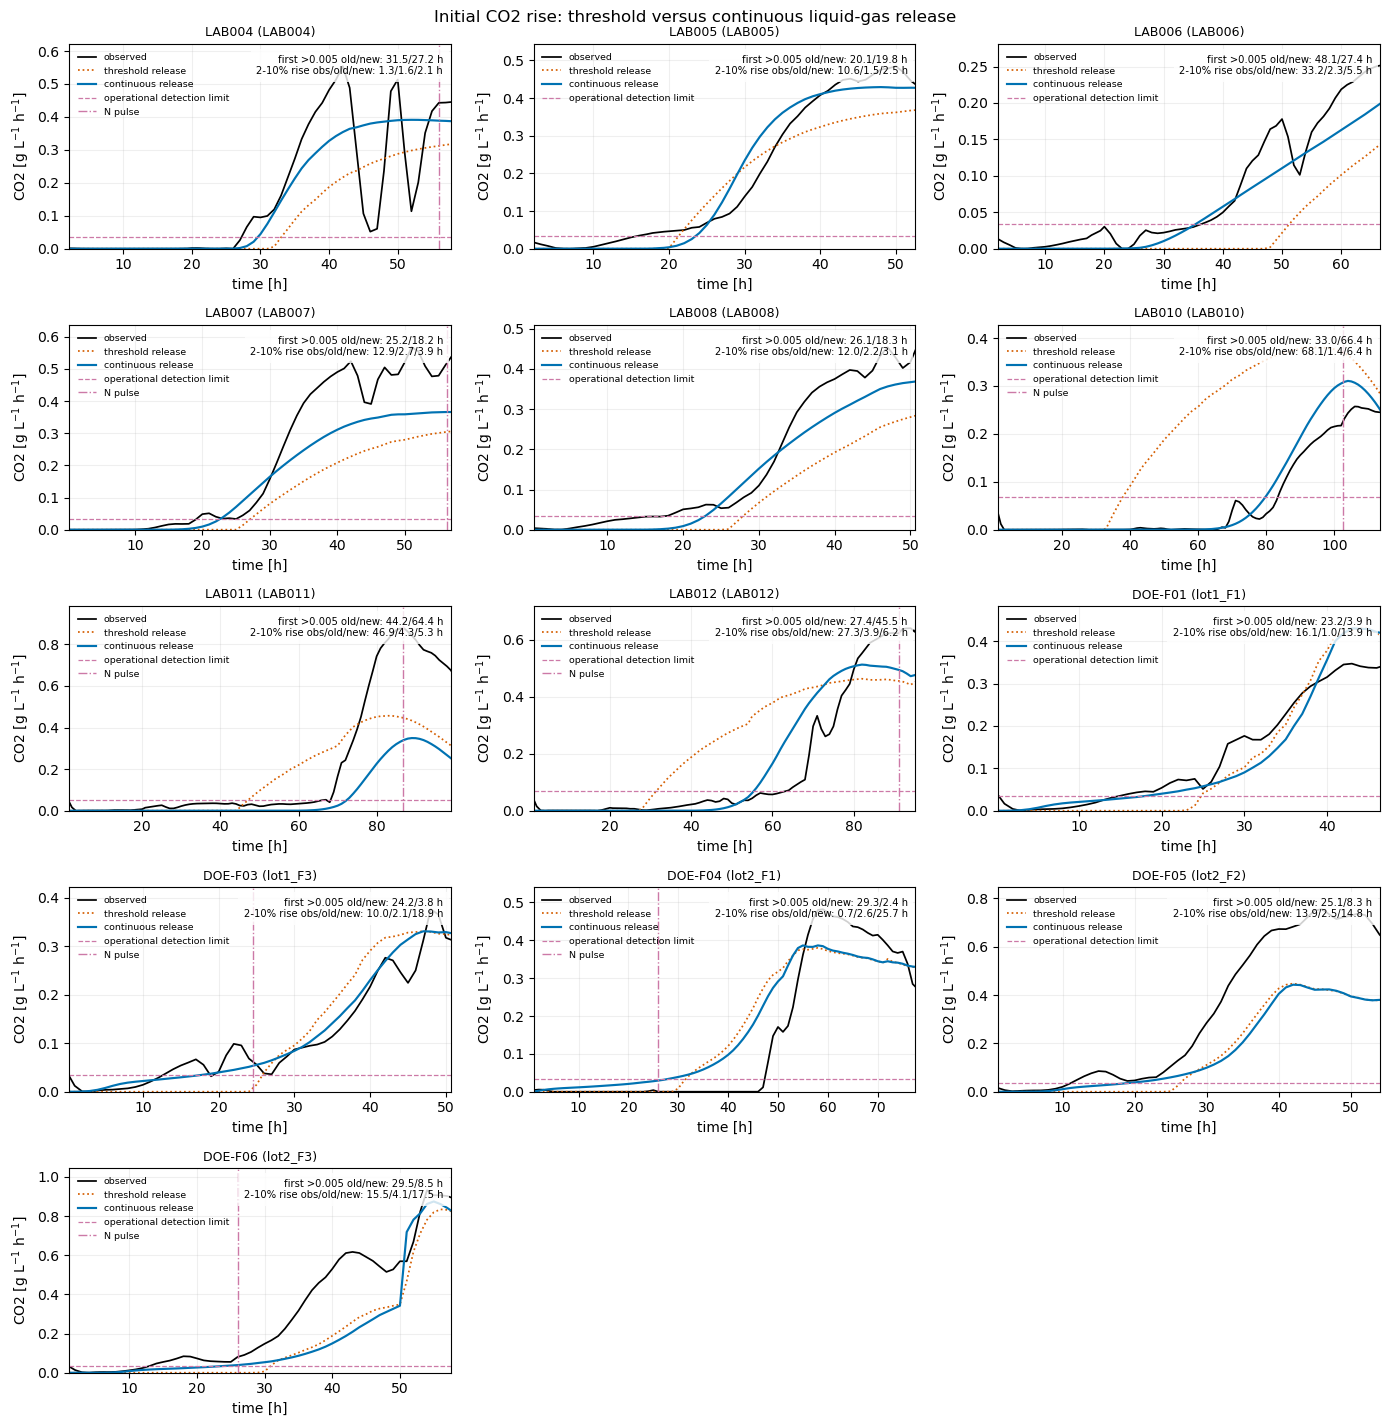

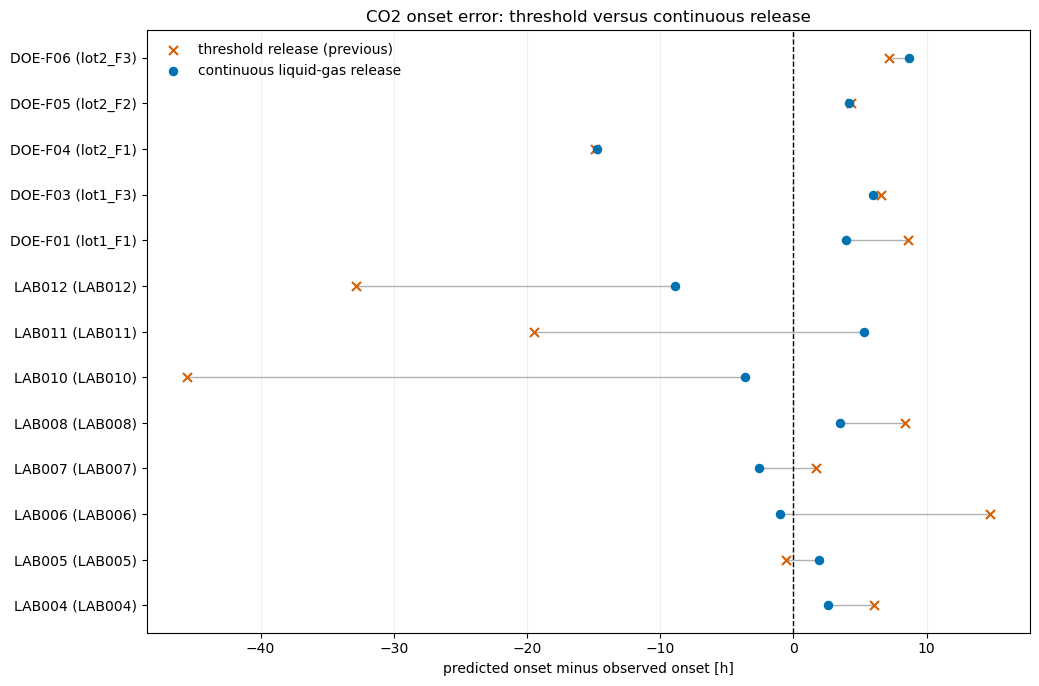

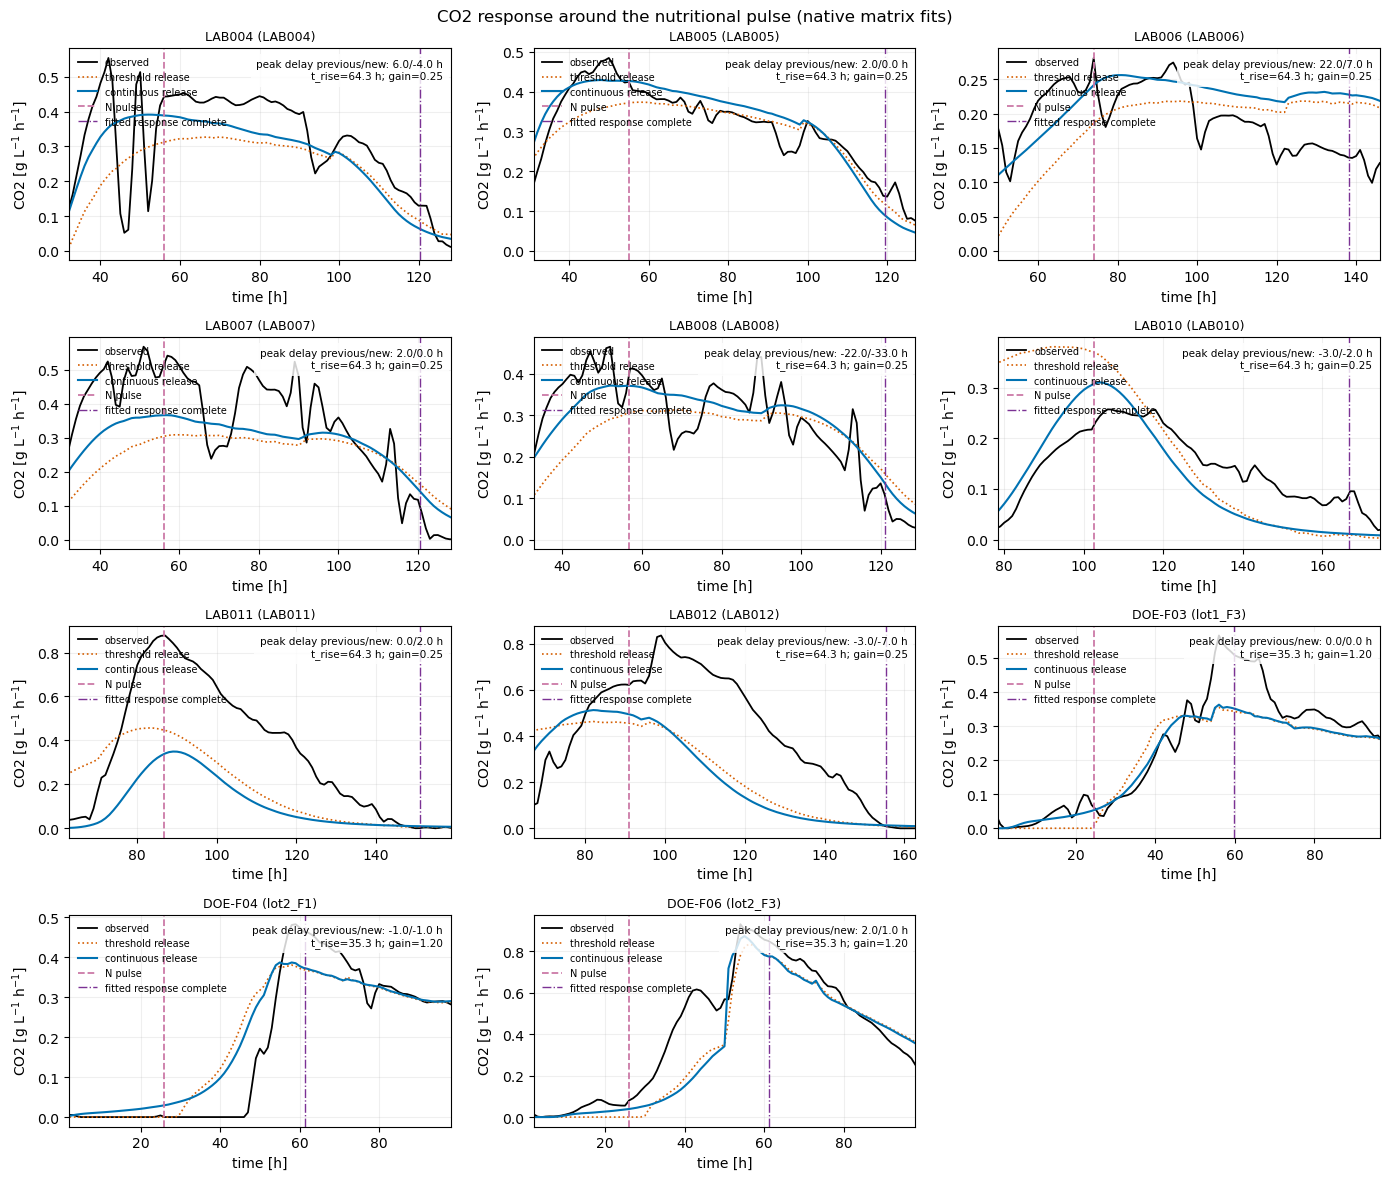

In [9]:
native_transition = result["source_transition_diagnostics"].query("native_matrix_fit").copy()
display(native_transition[[
    "target_matrix", "experiment_code", "batch", "median_setpoint_c",
    "cold_operation", "chemical_activity_lower_h", "chemical_activity_upper_h",
    "source_10pct_peak_onset_h", "o2_below_anaerobic_halfpoint_h",
    "observed_onset_h", "predicted_onset_h", "onset_delay_h",
    "O2_qmax_mg_gdw_h", "O2_initial_scale", "n_pulse_time_h",
    "pulse_t_rise_h", "pulse_activity_gain",
    "chem_activation_start_fraction", "chem_activation_duration_fraction",
    "pulse_utilization_complete_h",
    "observed_postpulse_peak_h", "predicted_postpulse_peak_h",
    "postpulse_peak_delay_h"
]])
fig = analysis.plot_initial_release_comparison(
    result["predictions"], result["previous_predictions"],
    result["batch_metrics"], result["previous_batch_metrics"], save=False
)
plt.show()
fig = analysis.plot_onset_model_comparison(
    result["batch_metrics"], result["previous_batch_metrics"], save=False
)
plt.show()
fig = analysis.plot_pulse_response_comparison(
    result["predictions"], result["previous_predictions"],
    result["batch_metrics"], result["previous_batch_metrics"],
    result["source_transition_diagnostics"], save=False
)
plt.show()

El primer gráfico es el control visual principal: amplía el inicio de cada lote y compara liberación por umbral (naranjo) con liberación continua (azul). La línea horizontal marca 0.005 g L⁻¹ h⁻¹; el texto cuantifica la primera emisión y la duración 2–10 %. El segundo resume el error de inicio. El tercero amplía cada lote pulsado: línea magenta = adición; línea morada = término de la disponibilidad gradual estimada.

## Validación retenida y transferencia cruzada

,scenario,calibration_matrix,target_matrix,experiment_code,batch,n,n_total,n_left_censored,rmse_g_l_h,nrmse_peak,bias_g_l_h,correlation,r2,integral_ratio_pred_over_observed_lower_bound,observed_onset_h,predicted_onset_h,onset_delay_h,predicted_first_emission_0p005_h,observed_visual_rise_duration_h,predicted_visual_rise_duration_h,visual_rise_duration_error_h,pulse_time_h,observed_postpulse_peak_h,predicted_postpulse_peak_h,postpulse_peak_delay_h
0,cross_matrix_holdout,synthetic,natural,LAB012,LAB012,98,161,63,0.344574,0.412435,-0.198728,0.082069,-1.060834,0.834944,65.156714,13.823893,-51.332821,5.569067,27.311566,5.028773,-22.282793,91.041739,99.0,97.0,-2.0
1,within_matrix_holdout,natural,natural,LAB012,LAB012,98,161,63,0.267236,0.319865,-0.163410,0.530159,-0.239557,0.606223,65.156714,56.253863,-8.902851,45.515952,27.311566,6.202978,-21.108588,91.041739,99.0,92.0,-7.0
2,cross_matrix_holdout,natural,synthetic,DOE-F06,lot2_F3,88,100,12,0.223098,0.239495,-0.199499,0.988583,0.318606,0.570313,27.509842,30.279101,2.769259,23.491868,15.479194,3.819548,-11.659647,26.000000,54.0,58.0,4.0
3,within_matrix_holdout,synthetic,synthetic,DOE-F06,lot2_F3,88,100,12,0.151561,0.162700,-0.077922,0.888842,0.685529,0.828388,27.509842,36.215465,8.705623,8.511975,15.479194,17.520545,2.041351,26.000000,54.0,55.0,1.0


,scenario,calibration_matrix,target_matrix,batch,experiment_code,rmse_g_l_h_threshold_release,nrmse_peak_threshold_release,correlation_threshold_release,r2_threshold_release,integral_ratio_pred_over_observed_lower_bound_threshold_release,observed_onset_h_threshold_release,predicted_onset_h_threshold_release,onset_delay_h_threshold_release,predicted_first_emission_0p005_h_threshold_release,observed_visual_rise_duration_h_threshold_release,predicted_visual_rise_duration_h_threshold_release,visual_rise_duration_error_h_threshold_release,observed_postpulse_peak_h_threshold_release,predicted_postpulse_peak_h_threshold_release,observed_pulse_t_rise_h_threshold_release,...,nrmse_peak_continuous_release,correlation_continuous_release,r2_continuous_release,integral_ratio_pred_over_observed_lower_bound_continuous_release,observed_onset_h_continuous_release,predicted_onset_h_continuous_release,onset_delay_h_continuous_release,predicted_first_emission_0p005_h_continuous_release,observed_visual_rise_duration_h_continuous_release,predicted_visual_rise_duration_h_continuous_release,visual_rise_duration_error_h_continuous_release,observed_postpulse_peak_h_continuous_release,predicted_postpulse_peak_h_continuous_release,observed_pulse_t_rise_h_continuous_release,predicted_pulse_t_rise_h_continuous_release,postpulse_peak_delay_h_continuous_release,rmse_change_continuous_minus_threshold_release,abs_onset_error_change_continuous_minus_threshold_release,abs_postpulse_peak_error_change_continuous_minus_threshold_release,abs_visual_rise_duration_error_change_continuous_minus_threshold_release
0,cross_matrix_holdout,synthetic,natural,LAB012,LAB012,0.337654,0.404152,0.134204,-0.978889,0.701212,65.156714,20.954824,-44.201890,19.107892,27.311566,1.392853,-25.918713,99.0,96.0,7.958261,...,0.412435,0.082069,-1.060834,0.834944,65.156714,13.823893,-51.332821,5.569067,27.311566,5.028773,-22.282793,99.0,97.0,7.958261,5.958261,-2.0,0.006920,7.130930,-1.0,-3.635920
1,within_matrix_holdout,natural,natural,LAB012,LAB012,0.272816,0.326545,0.358649,-0.291866,0.792406,65.156714,32.345957,-32.810757,27.408925,27.311566,3.883495,-23.428071,99.0,96.0,7.958261,...,0.319865,0.530159,-0.239557,0.606223,65.156714,56.253863,-8.902851,45.515952,27.311566,6.202978,-21.108588,99.0,92.0,7.958261,0.958261,-7.0,-0.005580,-23.907906,4.0,-2.319483
2,cross_matrix_holdout,natural,synthetic,lot2_F3,DOE-F06,0.277658,0.298065,0.967401,-0.055420,0.478203,27.509842,32.795527,5.285685,28.045606,15.479194,3.961730,-11.517465,54.0,62.0,28.000000,...,0.239495,0.988583,0.318606,0.570313,27.509842,30.279101,2.769259,23.491868,15.479194,3.819548,-11.659647,54.0,58.0,28.000000,32.000000,4.0,-0.054560,-2.516426,-4.0,0.142182
3,within_matrix_holdout,synthetic,synthetic,lot2_F3,DOE-F06,0.142093,0.152537,0.912343,0.723591,0.814661,27.509842,34.712220,7.202378,29.454237,15.479194,4.142484,-11.336711,54.0,56.0,28.000000,...,0.162700,0.888842,0.685529,0.828388,27.509842,36.215465,8.705623,8.511975,15.479194,17.520545,2.041351,54.0,55.0,28.000000,29.000000,1.0,0.009468,1.503245,-1.0,-9.295360


,calibration_matrix,target_matrix,batch,experiment_code,rmse_g_l_h_unfiltered_fit_common_support,nrmse_peak_unfiltered_fit_common_support,bias_g_l_h_unfiltered_fit_common_support,correlation_unfiltered_fit_common_support,r2_unfiltered_fit_common_support,rmse_g_l_h_filtered_censored,nrmse_peak_filtered_censored,bias_g_l_h_filtered_censored,correlation_filtered_censored,r2_filtered_censored,rmse_change
0,synthetic,natural,LAB012,LAB012,0.343742,0.411439,-0.202722,0.090581,-1.050890,0.344574,0.412435,-0.198728,0.082069,-1.060834,0.000832
1,natural,natural,LAB012,LAB012,0.236762,0.283390,-0.154737,0.667482,0.027026,0.267236,0.319865,-0.163410,0.530159,-0.239557,0.030474
2,natural,synthetic,lot2_F3,DOE-F06,0.274106,0.294251,-0.233918,0.955735,-0.028589,0.223098,0.239495,-0.199499,0.988583,0.318606,-0.051007
3,synthetic,synthetic,lot2_F3,DOE-F06,0.168463,0.180844,-0.109197,0.884779,0.611480,0.151561,0.162700,-0.077922,0.888842,0.685529,-0.016902


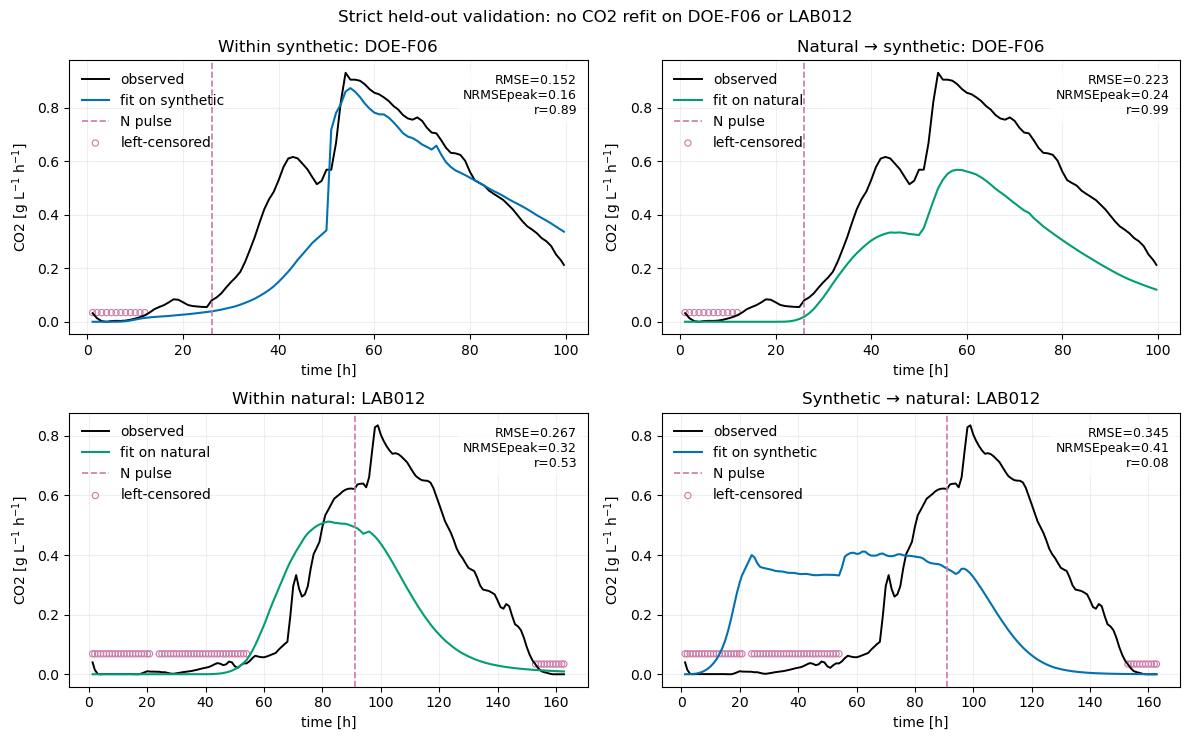

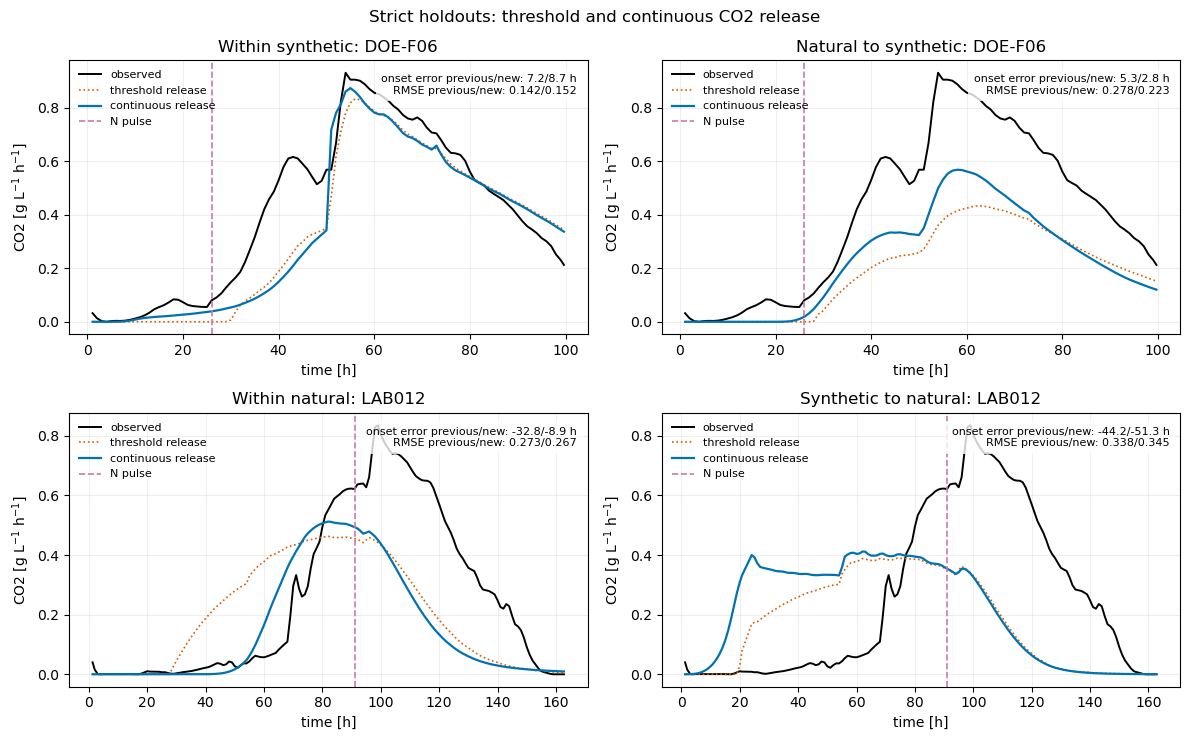

In [10]:
validation_columns = [
    "scenario", "calibration_matrix", "target_matrix", "experiment_code", "batch",
    "n", "n_total", "n_left_censored", "rmse_g_l_h", "nrmse_peak", "bias_g_l_h",
    "correlation", "r2", "integral_ratio_pred_over_observed_lower_bound",
    "observed_onset_h", "predicted_onset_h", "onset_delay_h",
    "predicted_first_emission_0p005_h", "observed_visual_rise_duration_h",
    "predicted_visual_rise_duration_h", "visual_rise_duration_error_h",
    "pulse_time_h", "observed_postpulse_peak_h", "predicted_postpulse_peak_h",
    "postpulse_peak_delay_h"
]
display(result["validation"][validation_columns])
display(result["model_comparison"])
display(result["filter_impact"])
fig = analysis.plot_validation(result["predictions"], result["validation"], save=False)
plt.show()
fig = analysis.plot_validation_model_comparison(
    result["predictions"], result["previous_predictions"],
    result["validation"], result["previous_validation"], save=False
)
plt.show()

`model_comparison` usa exactamente los mismos holdouts para la liberación por umbral anterior y la liberación continua nueva, conservando la misma respuesta finita al pulso. Valores negativos en las columnas `*_change_continuous_minus_threshold_release` significan mejora. `filter_impact` compara los ajustes crudo y filtrado sobre el mismo soporte cuantificable.

## Diagnóstico por fermentación

In [11]:
display(result["batch_metrics"][[
    "calibration_matrix", "target_matrix", "experiment_code", "batch", "role",
    "n", "n_left_censored", "rmse_g_l_h", "nrmse_peak", "bias_g_l_h",
    "correlation", "integral_ratio_pred_over_observed_lower_bound",
    "observed_onset_h", "predicted_onset_h", "onset_delay_h", "pulse_time_h",
    "predicted_first_emission_0p005_h", "observed_visual_rise_duration_h",
    "predicted_visual_rise_duration_h", "visual_rise_duration_error_h",
    "observed_postpulse_peak_h", "predicted_postpulse_peak_h",
    "postpulse_peak_delay_h"
]].sort_values(["calibration_matrix", "target_matrix", "batch"]))

,calibration_matrix,target_matrix,experiment_code,batch,role,n,n_left_censored,rmse_g_l_h,nrmse_peak,bias_g_l_h,correlation,integral_ratio_pred_over_observed_lower_bound,observed_onset_h,predicted_onset_h,onset_delay_h,pulse_time_h,predicted_first_emission_0p005_h,observed_visual_rise_duration_h,predicted_visual_rise_duration_h,visual_rise_duration_error_h,observed_postpulse_peak_h,predicted_postpulse_peak_h,postpulse_peak_delay_h
13,natural,natural,LAB004,LAB004,calibration,97,65,0.101551,0.183337,-0.043913,0.728627,0.878423,27.735273,30.350424,2.615151,56.091667,27.225540,1.308296,2.109304,0.801009,61.0,57.0,-4.0
14,natural,natural,LAB005,LAB005,calibration,119,43,0.042585,0.087861,0.005827,0.961204,1.018778,22.576040,24.531517,1.955477,55.086614,19.798182,10.599277,2.526200,-8.073077,56.0,56.0,0.0
15,natural,natural,LAB006,LAB006,calibration,139,71,0.073375,0.261058,0.040861,0.580582,1.269777,36.543760,35.523228,-1.020532,74.000000,27.410366,33.181485,5.457299,-27.724186,74.0,81.0,7.0
16,natural,natural,LAB007,LAB007,calibration,101,60,0.111951,0.197212,-0.065388,0.847910,0.845841,26.797300,24.191594,-2.605706,56.246154,18.201531,12.900109,3.932705,-8.967404,57.0,57.0,0.0
17,natural,natural,LAB008,LAB008,calibration,114,47,0.057739,0.124186,-0.001189,0.897634,0.999116,20.661926,24.185345,3.523418,56.750000,18.302770,12.036962,3.135186,-8.901776,90.0,57.0,-33.0
18,natural,natural,LAB010,LAB010,calibration,84,101,0.065501,0.254635,-0.026149,0.877936,0.830561,83.423205,79.775935,-3.647270,102.494530,66.410671,68.111733,6.404286,-61.707447,106.0,104.0,-2.0
19,natural,natural,LAB011,LAB011,calibration,76,85,0.346934,0.395373,-0.311977,0.956993,0.296372,68.971501,74.290315,5.318814,86.836735,64.359855,46.946272,5.258242,-41.688029,87.0,89.0,2.0
20,natural,natural,LAB012,LAB012,internal_holdout,98,63,0.267236,0.319865,-0.163410,0.530159,0.606223,65.156714,56.253863,-8.902851,91.041739,45.515952,27.311566,6.202978,-21.108588,99.0,92.0,-7.0
21,natural,synthetic,DOE-F01,lot1_F1,cross_context,178,35,0.169582,0.469961,0.158309,0.875647,2.074872,16.399541,23.154138,6.754597,NaN,19.466890,16.149541,2.070559,-14.078982,NaN,NaN,NaN
22,natural,synthetic,DOE-F03,lot1_F3,cross_context,156,57,0.141863,0.250230,-0.076683,0.528955,0.682944,20.640551,24.003549,3.362998,24.500000,19.087220,10.049108,2.681516,-7.367593,56.0,40.0,-16.0


## Experimento pendiente para distinguir sensor de biología

El umbral dependiente de temperatura sigue siendo operacional, no un LOD/LOQ certificado. Para identificarlo se requiere un ensayo a 15, 18 y 21 °C con el mismo medio y volumen, referencia independiente de CO₂ y escalones de 0.01–0.30 g CO₂ L⁻¹ h⁻¹. En cada temperatura deben estimarse LOD, LOQ, sesgo, repetibilidad y tiempo de respuesta.

La corrección por percentil inicial también es operacional. Debe reemplazarse por blancos de gas sin fermentación medidos al comienzo y al final de cada corrida en cada canal. Eso separaría offset, deriva y flujo biológico temprano sin depender de una ventana temporal elegida.

La validación biológica complementaria debe iniciar con medición química frecuente durante las primeras 48–72 h, especialmente en frío, para estrechar el intervalo de activación. Sin ese muestreo, la química sólo identifica un intervalo y no un instante exacto.

## Resumen reproducible

In [12]:
print("SCCM_CORRECTED:", result["manifest"]["sccm_conversion"]["factor_g_l_h_per_sccm_at_2L"], "g/L/h/SCCM")
display(result["state_objectives"])
print()
print("matrix_gain (parámetro empírico de observación):")
display(result["matrix_gain_compensation"])

direct = result["pairwise_shape_scale"].query("transition == 'A_to_B'")
native = direct.query("calibration_matrix == target_matrix")
print()
print("Batches más sensibles a A→B (fits nativos):")
display(native.nlargest(8, "direct_prediction_rmse_g_l_h")[[
    "calibration_matrix", "target_matrix", "experiment_code", "batch", "role",
    "direct_prediction_rmse_g_l_h", "best_multiplicative_scale_right_from_left",
    "shape_rmse_after_best_scale_g_l_h", "fraction_squared_change_explained_by_scale",
    "integral_ratio_right_over_left", "peak_ratio_right_over_left", "peak_time_change_h"
]])

print()
print("Holdouts y transferencia A/B/C:")
display(result["state_validation"])
print()
print("Parámetros en límite por estado:")
display(result["state_parameters"].query("active_bound"))
print()
print("Identificabilidad local A vs C:")
display(result["identifiability_state_comparison"])
print()
print("Artefactos:", analysis.RESULTS_DIR.relative_to(ROOT))

SCCM_CORRECTED: 0.0404391928807947 g/L/h/SCCM


,state,matrix,wsse_equal_batch_fixed_co2,n_residuals,matrix_gain,co2_refitted
0,A_historical,synthetic,19.515601,632,1.459910,False
1,A_historical,natural,27.952095,1216,2.139011,False
2,A_historical,all,47.467696,1848,NaN,False
3,B_full_theta_no_refit,synthetic,27.810253,632,1.459910,False
4,B_full_theta_no_refit,natural,54.472866,1216,2.139011,False
5,B_full_theta_no_refit,all,82.283119,1848,NaN,False
6,C_full_theta_refit,synthetic,18.908940,632,1.149648,True
7,C_full_theta_refit,natural,29.341781,1216,1.542283,True
8,C_full_theta_refit,all,48.250721,1848,NaN,True



matrix_gain (parámetro empírico de observación):


,matrix,historical_matrix_gain,refit_matrix_gain,absolute_change,percent_change,direct_raw_integral_ratio_B_over_A,gain_ratio_C_over_A,gain_only_compensated_ratio_to_A,other_co2_layer_raw_ratio_C_over_B,final_scaled_integral_ratio_C_over_A,interpretation_guardrail
0,synthetic,1.459910,1.149648,-0.310262,-21.252106,1.279092,0.787479,1.007258,1.002452,1.009727,matrix_gain is an empirical observation/scale ...
1,natural,2.139011,1.542283,-0.596728,-27.897366,1.185122,0.721026,0.854505,1.039211,0.888011,matrix_gain is an empirical observation/scale ...



Batches más sensibles a A→B (fits nativos):


...


Parámetros en límite por estado:


,state,calibration_matrix,parameter,estimate,lower_bound,upper_bound,active_bound,relative_bound_distance,co2_refitted
2,A_historical,synthetic,O2_qmax_mg_gdw_h,0.150164,0.15,6.00,True,2.956649e-04,False
6,A_historical,synthetic,chem_activation_start_fraction,0.010004,0.01,0.95,True,8.809663e-05,False
7,A_historical,synthetic,chem_activation_duration_fraction,0.350000,0.35,2.00,True,1.204971e-09,False
10,A_historical,natural,CO2sat_scale,0.350040,0.35,2.50,True,5.834029e-05,False
11,A_historical,natural,O2_qmax_mg_gdw_h,0.150000,0.15,6.00,True,1.859963e-14,False
14,A_historical,natural,pulse_activity_gain,0.250000,0.25,4.00,True,0.000000e+00,False
20,B_full_theta_no_refit,synthetic,O2_qmax_mg_gdw_h,0.150164,0.15,6.00,True,2.956649e-04,False
24,B_full_theta_no_refit,synthetic,chem_activation_start_fraction,0.010004,0.01,0.95,True,8.809663e-05,False
25,B_full_theta_no_refit,synthetic,chem_activation_duration_fraction,0.350000,0.35,2.00,True,1.204971e-09,False
28,B_full_theta_no_refit,natural,CO2sat_scale,0.350040,0.35,2.50,True,5.834029e-05,False



Identificabilidad local A vs C:


,state,matrix,n_residuals,n_shape_parameters,effective_rank,condition_number_log_parameter_jacobian,smallest_singular_value,largest_singular_value,residual_variance_scale,interpretation
0,A_historical,synthetic,632,8,8,2.924571e+07,2.660739e-07,7.781522,0.031275,ill_conditioned
1,A_historical,natural,1216,8,8,1.297731e+02,7.874208e-02,10.218605,0.023139,moderate_or_better
2,C_full_theta_refit,synthetic,632,8,8,9.076098e+10,3.373549e-08,3061.865826,0.030303,ill_conditioned
3,C_full_theta_refit,natural,1216,8,8,1.374952e+07,8.860414e-07,12.182643,0.024290,ill_conditioned



Artefactos: fermentation_model\laboratory_2026\results\co2_matrix_cross_validation_2026_full_theta_sccm_corrected


## Artefactos

La ejecución guarda la suite completa histórica para el estado C y, además, theta auditados,
reconstrucción del fallback, predicciones/métricas A–B–C, cambios pareados, separación escala/forma,
compensación de `matrix_gain` e identificabilidad A versus C. Todos los artefactos se escriben en
`results/co2_matrix_cross_validation_2026_full_theta_sccm_corrected/`.